In [1]:
import torch
from torch import nn
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
from rt_whisper.models.boundary_word_filter import BoundaryWordFilter

/workspaces/dev/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
EXPONENT = 2
MODELS = {
    "baseline": {
        "path": "/workspaces/dev/test/optimize/all/model_weight/model-pt-96k_3s_96bu.pth",
        "overlap_length": 96_000,
        "chunk_length": 48_000,
        "boundary": 96_000,
    },
    "test-3s": {
        "path": "/workspaces/dev/test/optimize/esic/hyperparameters/20250917/3s/step2_3s-96k-cpm/001_0_046_model.pth",
        "overlap_length": 96_000,
        "chunk_length": 48_000,
        "boundary": 96_000,
    },
    "test-2s": {
        "path": "/workspaces/dev/test/optimize/esic/hyperparameters/20250917/2s/step2_2s-96k-cpm/001_0_047_model.pth",
        "overlap_length": 96_000,
        "chunk_length": 32_000,
        "boundary": 96_000,
    },
    "test-1s": {
        "path": "/workspaces/dev/test/optimize/esic/hyperparameters/20250917/1s/step2_1s-96k-cpm/001_0_047_model.pth",
        "overlap_length": 96_000,
        "chunk_length": 16_000,
        "boundary": 96_000,
    },
}

In [4]:
models = {k: Path(v["path"]) for k, v in MODELS.items()}

if not all(m.exists() for m in models.values()):
    raise FileNotFoundError(f"One or more model files do not exist: {models}")

In [5]:
b_models = {k: BoundaryWordFilter.load(v) for k, v in models.items()}

In [6]:
def generate_data(
    size:int,
    length:int,
    dur:int = -1
):
    b = np.random.randint(0, length+1, 2 * size).reshape(size, 2)
    start, end = b.min(axis=1).astype(np.int32), b.max(axis=1).astype(np.int32)
    start = (start // 160) * 160
    end = (end // 160) * 160

    if dur > 0:
        mask = (start + dur) <= length
        end[mask] = start[mask] + dur
        start[~mask] = end[~mask] - dur

        neg = start < 0
        if np.any(neg):
            start[neg] = 0
            end[neg] = dur

    mid = (start + end) // 2

    return start, end, mid

def preprocess_data(
    start:np.ndarray,
    end:np.ndarray,
    mid:np.ndarray,
    length:int,
    boundary:int
):
    ss = np.clip(start/ boundary, 0, 1)
    se = np.clip(end/ boundary, 0, 1)
    es = np.clip((length - start) / boundary, 0, 1)
    ee = np.clip((length - end) / boundary, 0, 1)
    sm = np.clip(mid / boundary, 0, 1)
    em = np.clip((length - mid) / boundary, 0, 1)

    return np.stack([ss, se, es, ee, sm, em], axis=1).astype(np.float32)

def approximate_data(
    mid:np.ndarray,
    length:int,
    boundary:int,
    exponent:float = EXPONENT
):
    near = np.minimum(mid, length - mid)
    y = np.clip(near / boundary, 0, 1) ** exponent
    y = y.astype(np.float32)

    return y

def predict(
    model: nn.Module,
    X: torch.Tensor,
    device: str | torch.device = "cpu"
):
    model.to(device)
    X = X.to(device)

    with torch.no_grad():
        preds = model(X).cpu().numpy().flatten()

    return preds

def plot_mid_with_pred_and_approx(
    mid: np.ndarray,
    preds: np.ndarray,
    approx: np.ndarray,
):
    # 산점도 그리기
    plt.figure(figsize=(8,5))
    plt.scatter(mid, approx, alpha=0.5, label="Target (Y)", color="blue")
    plt.scatter(mid, preds, alpha=0.5, label="Model Output", color="red")
    plt.xlabel("mid")
    plt.ylabel("value")
    plt.title("Mid vs Model Prediction & Target")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlim(0, 150_000)
    plt.show()

def plot_bar_with_pred_and_approx(
    start: np.ndarray,
    end: np.ndarray,
    mid: np.ndarray,
    preds: np.ndarray,
    approx: np.ndarray,
):
    plt.figure(figsize=(10, 10))

    # Target (approx) 바
    # plt.hlines(approx, start, end, colors="blue", linestyles="-", linewidth=3, alpha=0.2, label="Target (Y)")
    # plt.scatter(mid, approx, color="yellow", s=30, alpha=0.5)

    # Model output (preds) 바
    plt.hlines(preds, start, end, colors="red", linestyles="-", linewidth=3, alpha=0.2, label="Model Output")
    plt.scatter(mid, preds, color="cyan", s=30, alpha=0.5)

    plt.xlabel("time")
    plt.ylabel("value")
    plt.title("Start~End Bars with Midpoints")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.xlim(0, 150_000)
    plt.show()

In [10]:
def plot_with_dur(model:nn.Module, datasets:dict, device: str|torch.device = "cpu", mask_ratio:float=0.1):
    all_start, all_end, all_mid, all_preds, all_approx = [], [], [], [], []
    for dur, data in datasets.items():
        # print(f"========================= {dur} ===============================")

        preds = predict(model, data["x"], device)
        plot_mid_with_pred_and_approx(data["mid"], preds, data["y"])

        all_start.append(data["start"])
        all_end.append(data["end"])
        all_mid.append(data["mid"])
        all_preds.append(preds)
        all_approx.append(data["y"])

    start = np.concatenate(all_start)
    end = np.concatenate(all_end)
    mid = np.concatenate(all_mid)
    preds = np.concatenate(all_preds)
    approx = np.concatenate(all_approx)
    mask = np.random.rand(len(start)) < mask_ratio
    start, end, mid, preds, approx = start[mask], end[mask], mid[mask], preds[mask], approx[mask]
    plot_bar_with_pred_and_approx(start, end, mid, preds, approx)

baseline


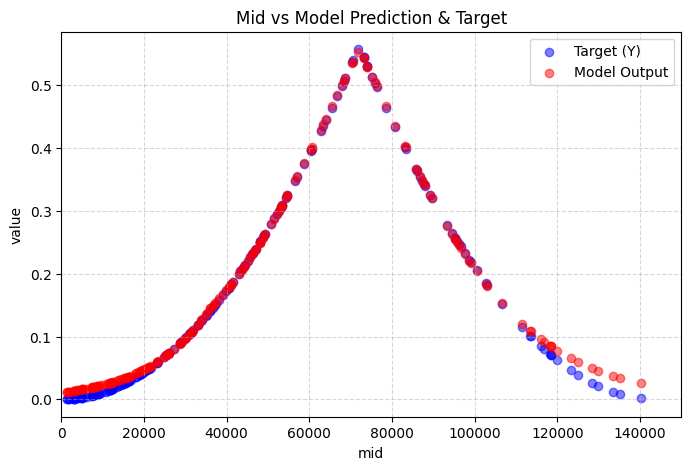

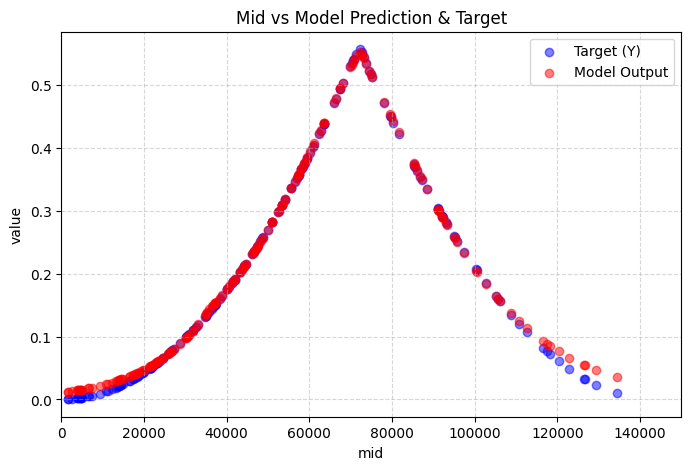

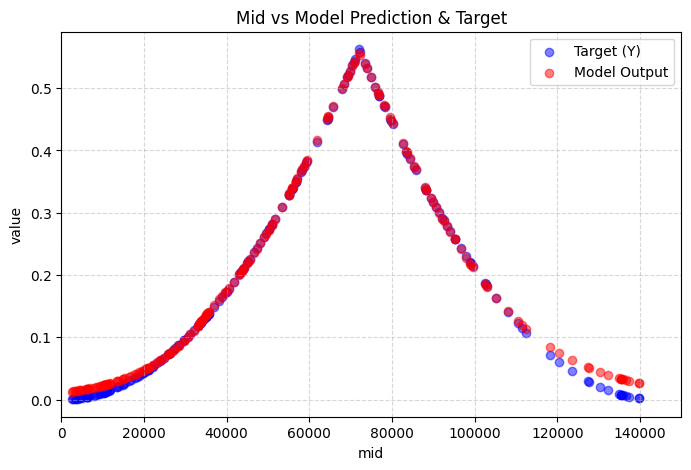

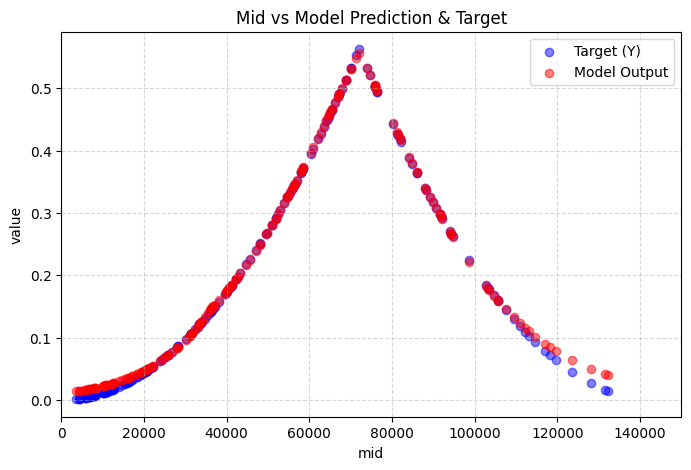

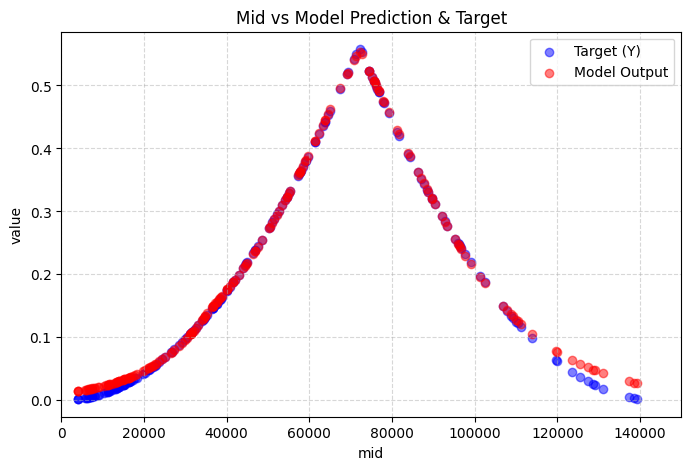

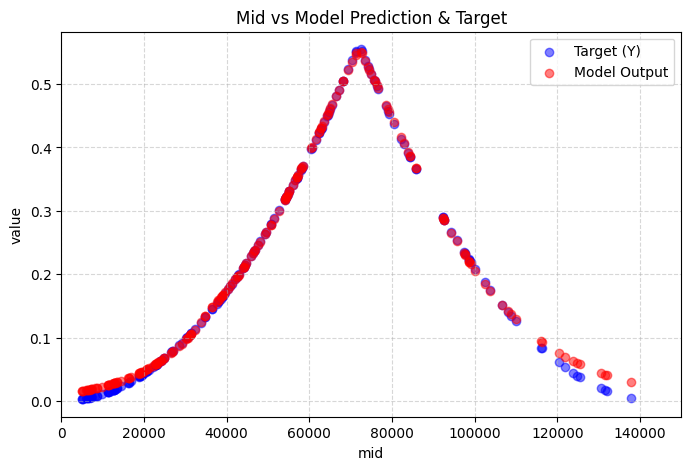

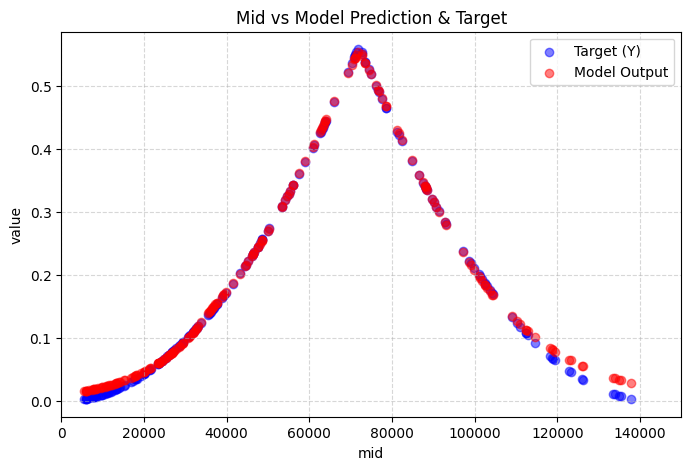

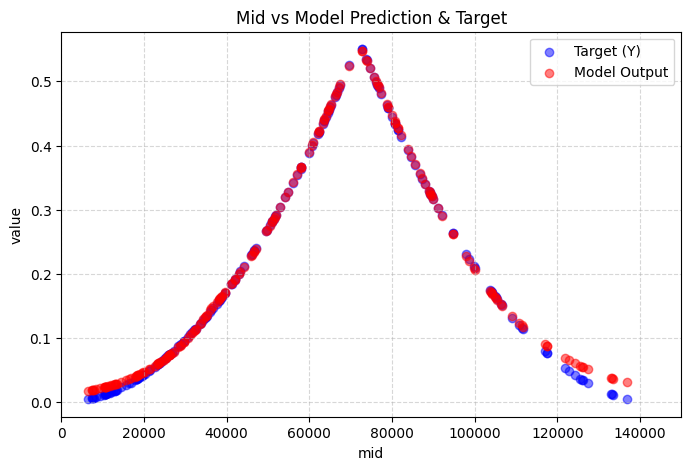

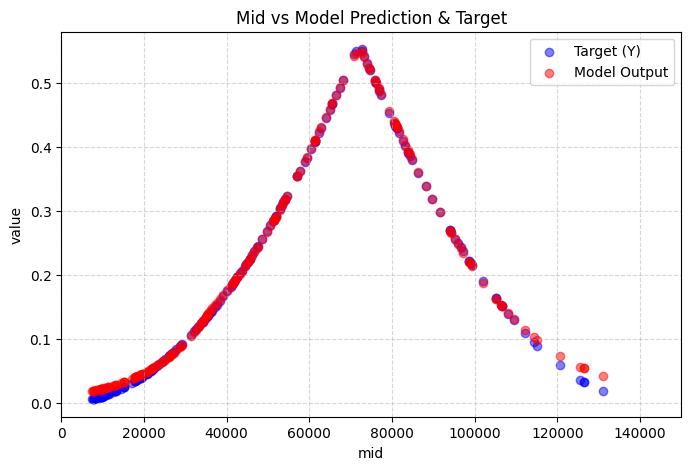

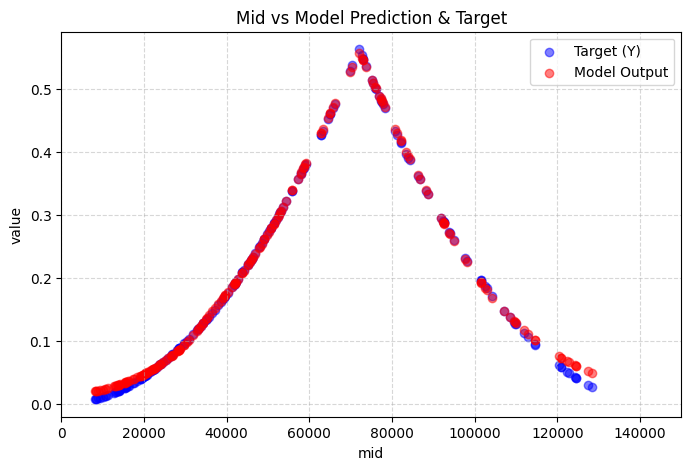

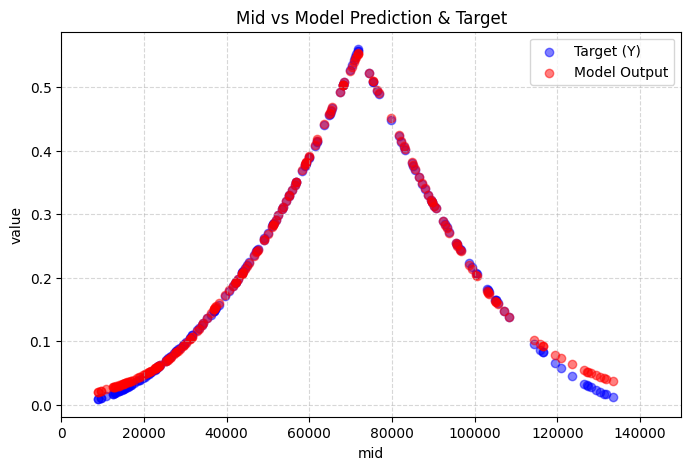

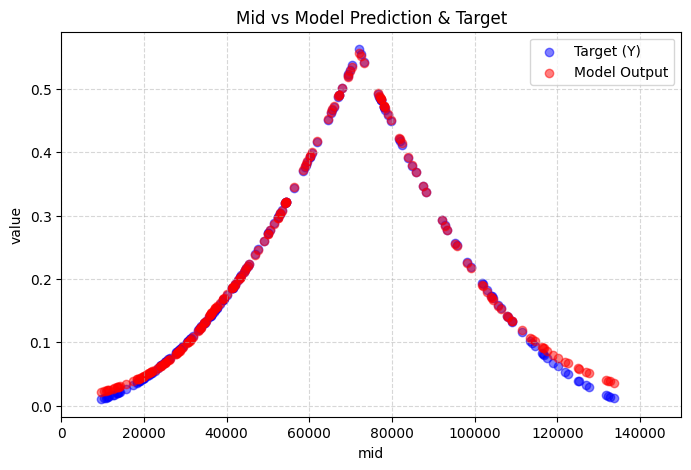

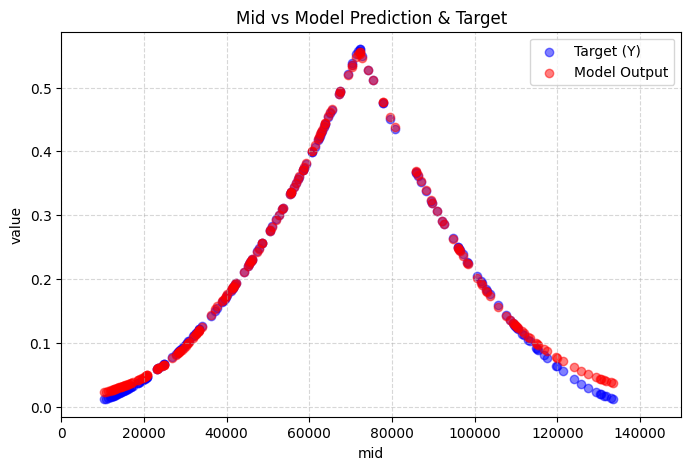

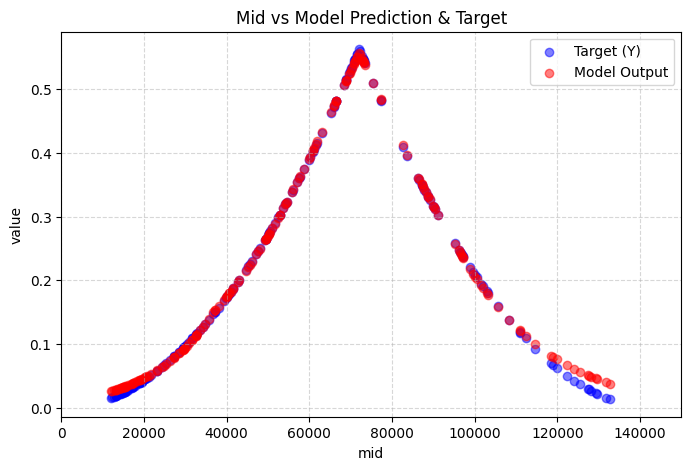

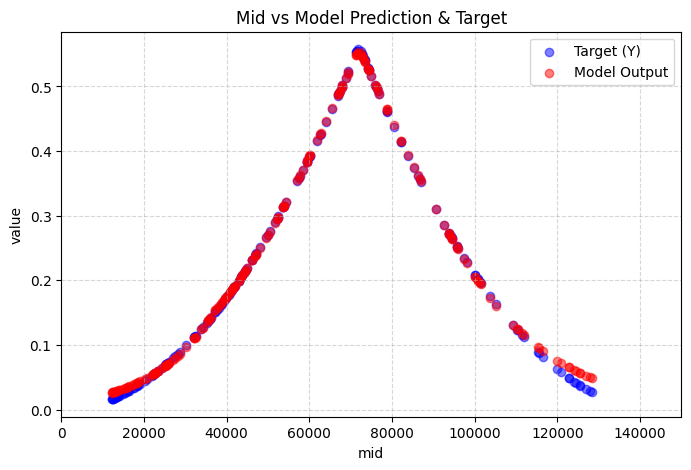

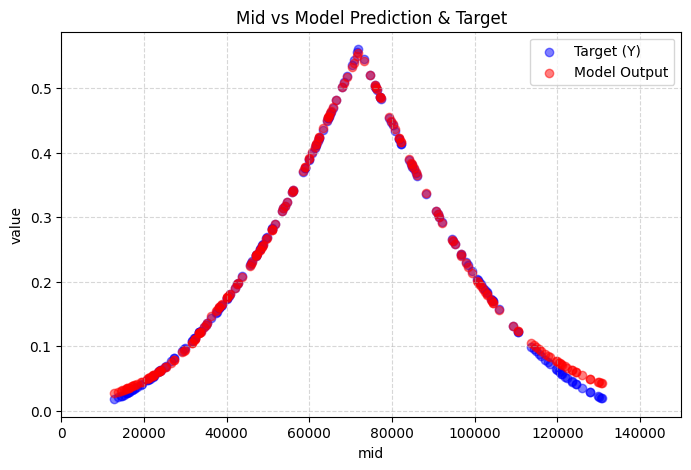

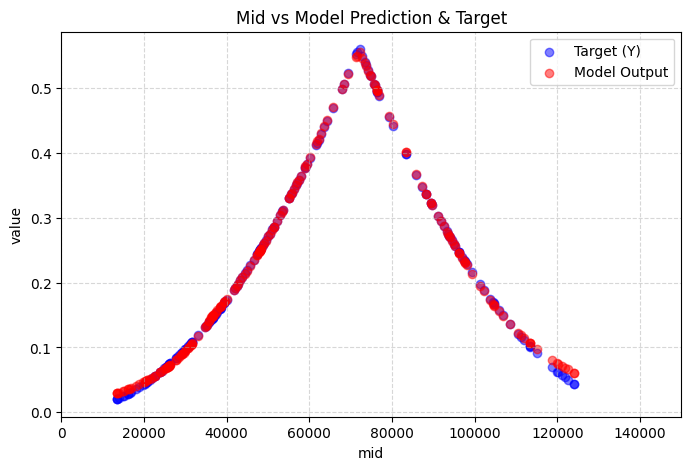

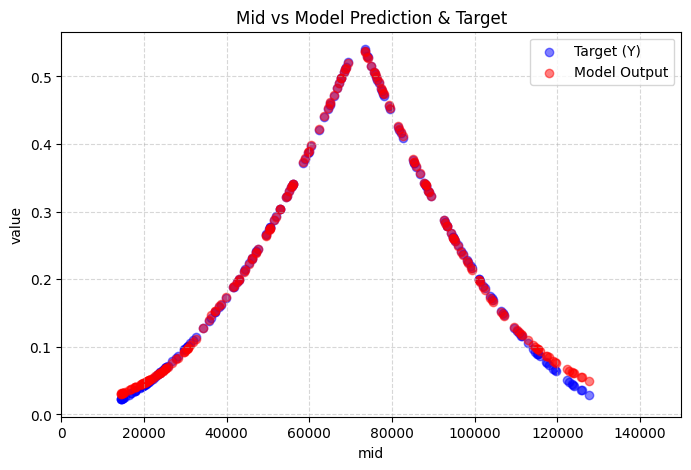

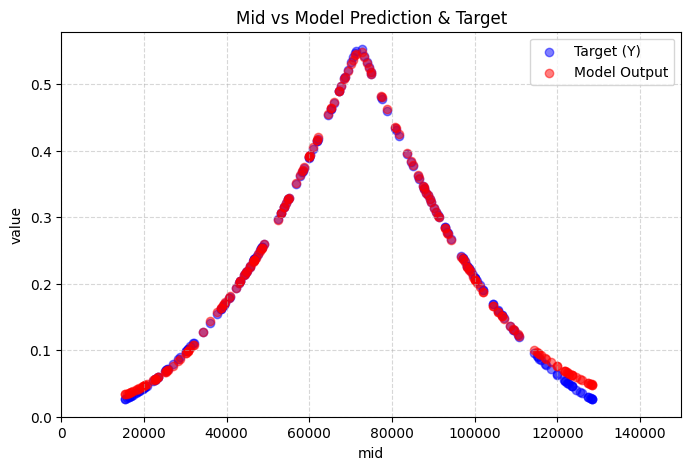

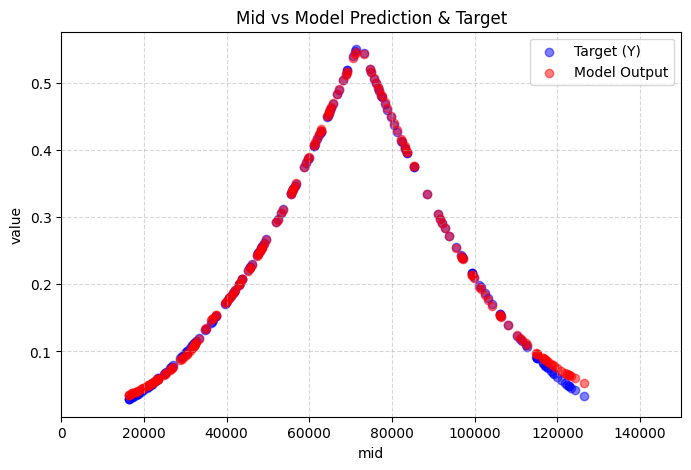

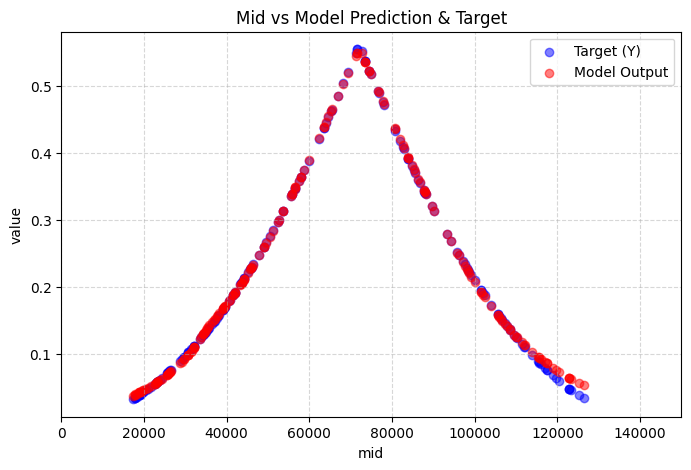

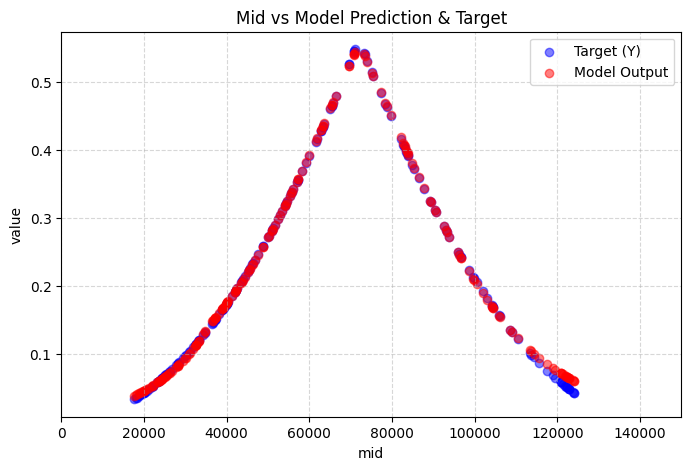

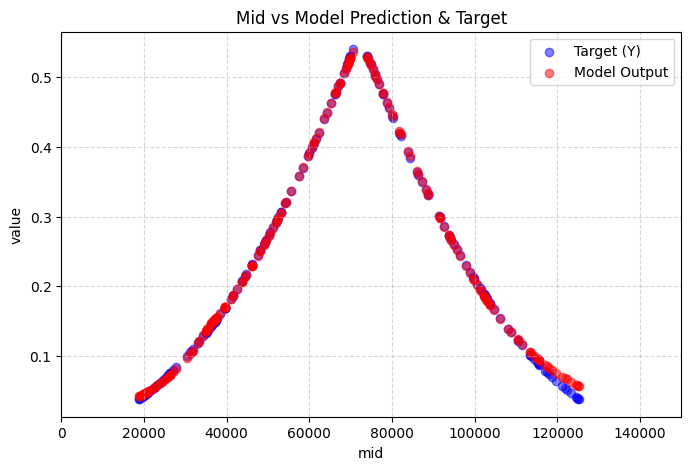

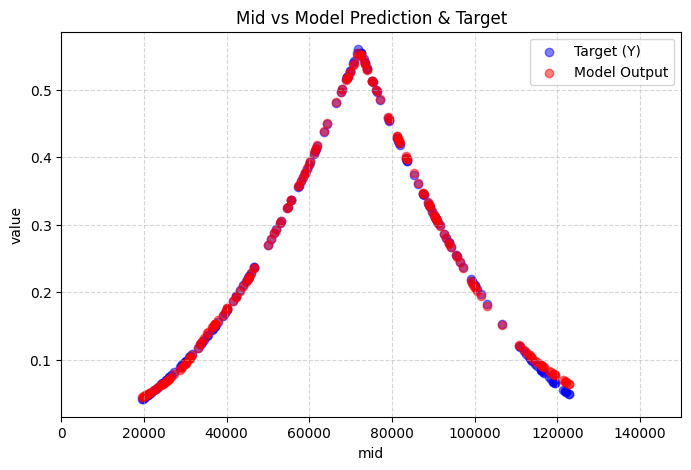

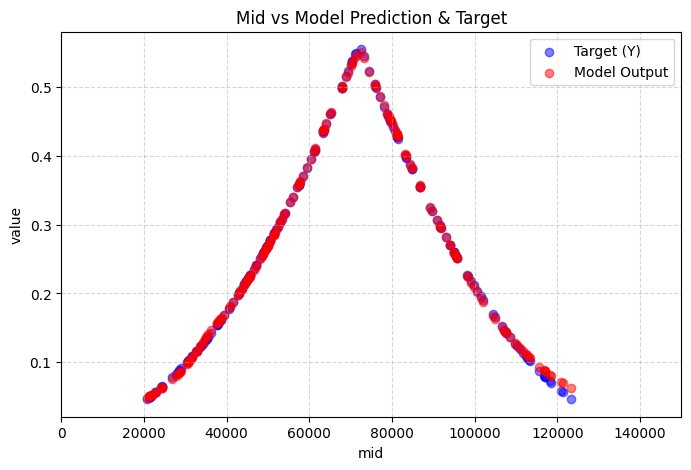

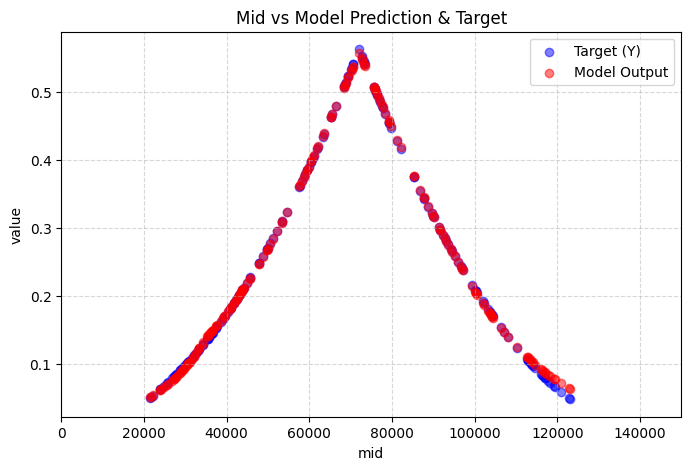

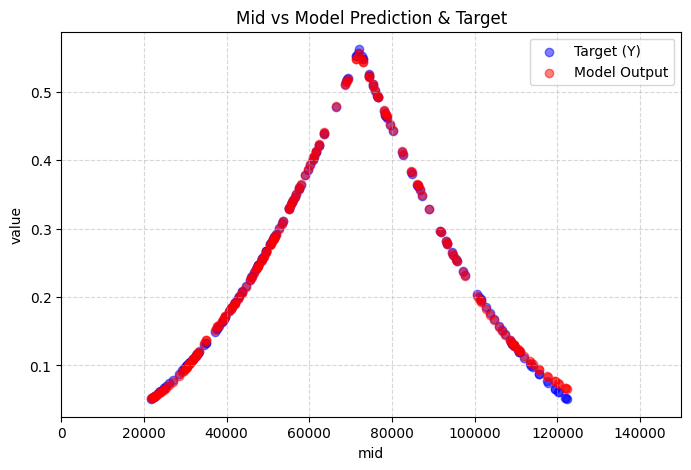

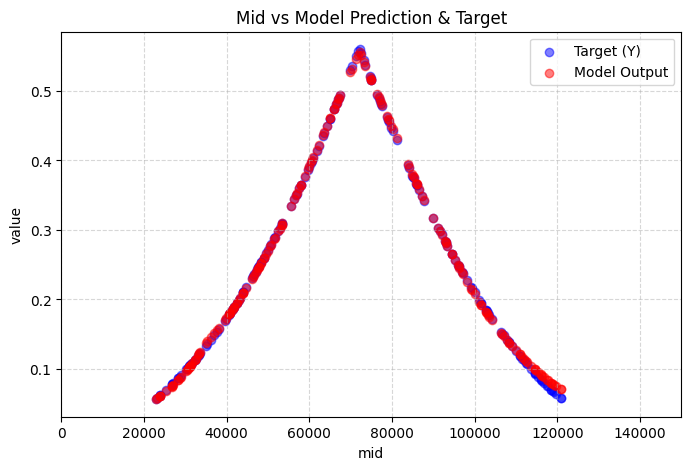

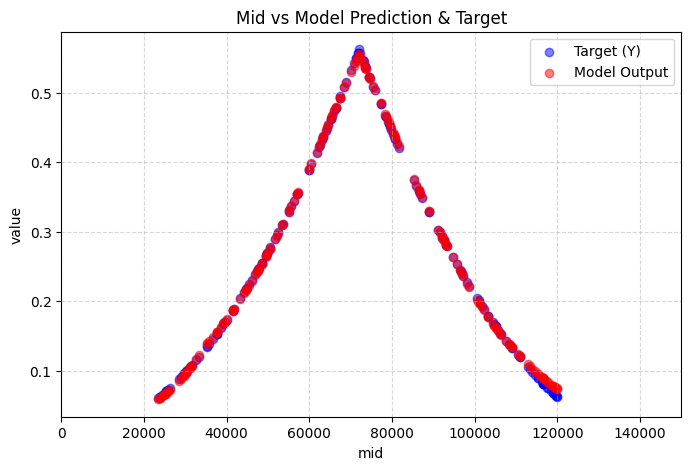

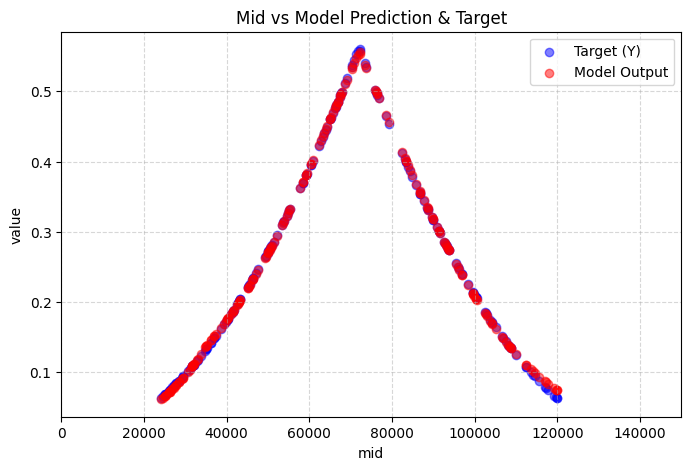

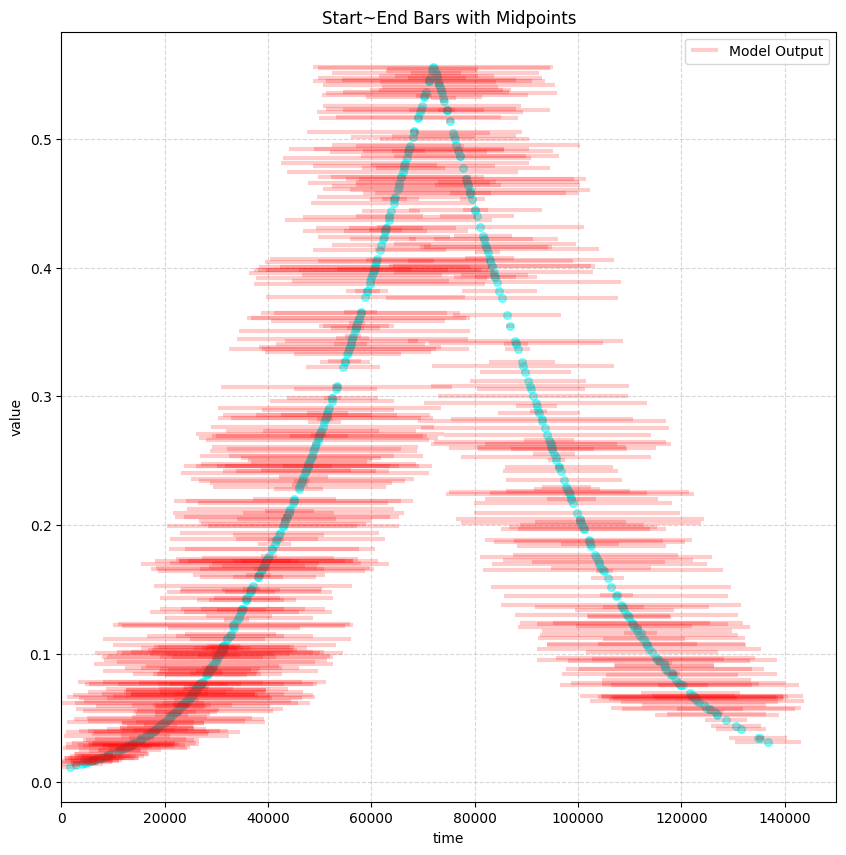

test-3s


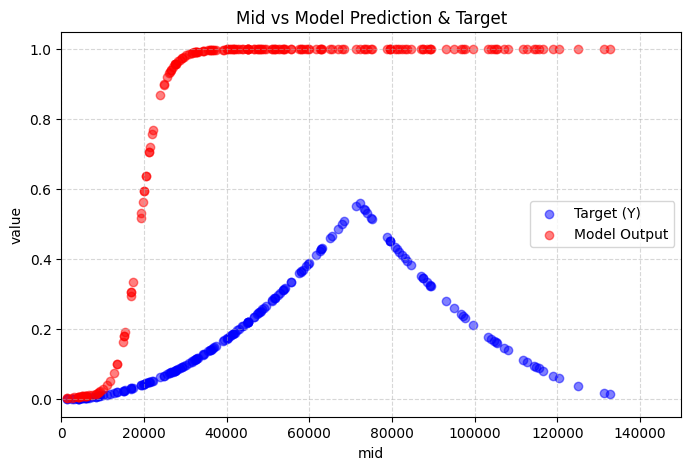

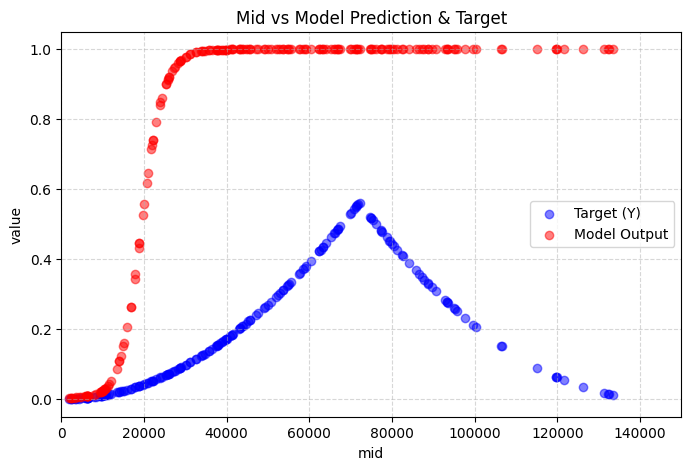

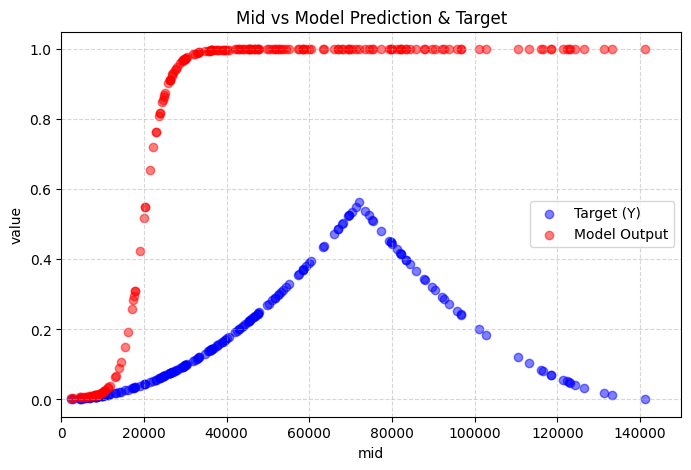

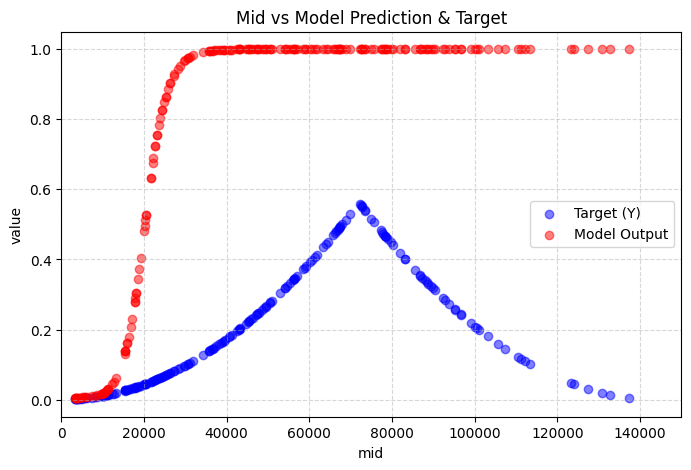

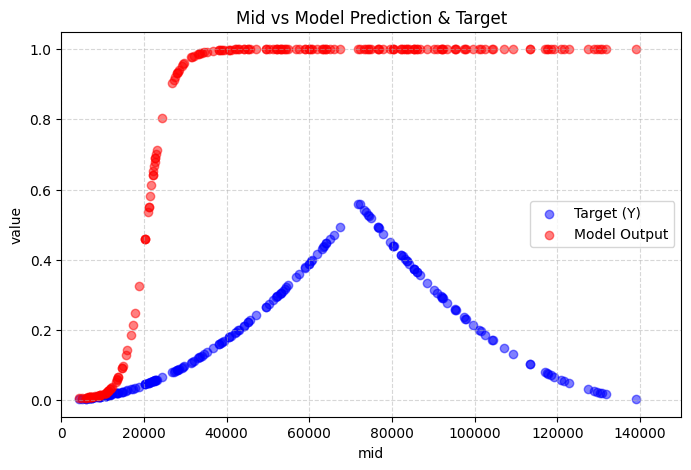

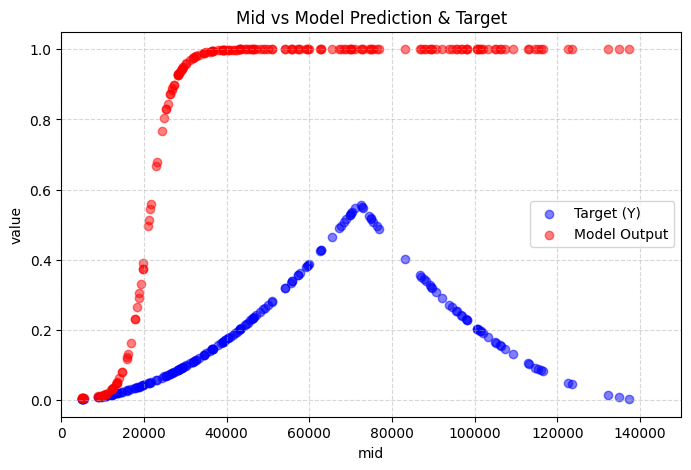

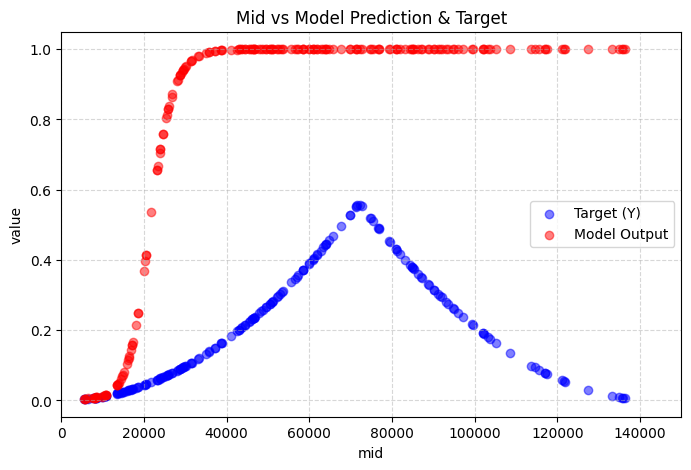

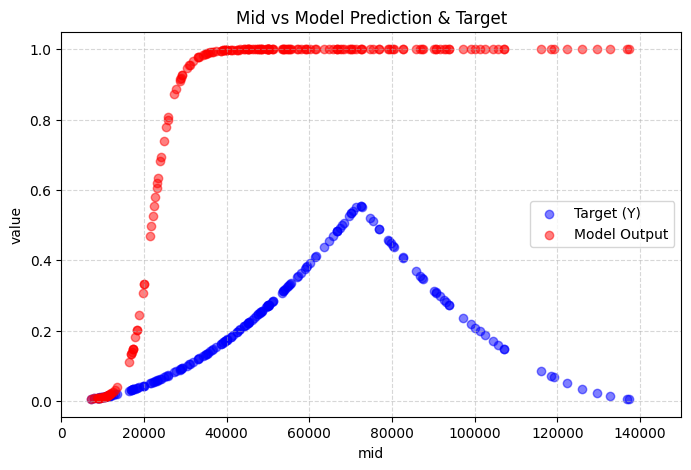

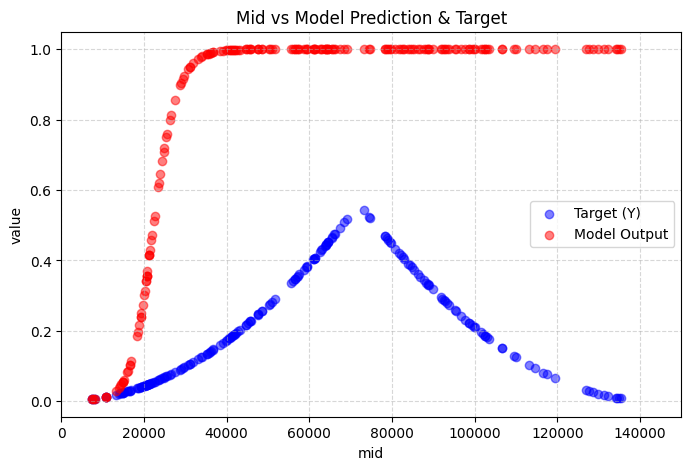

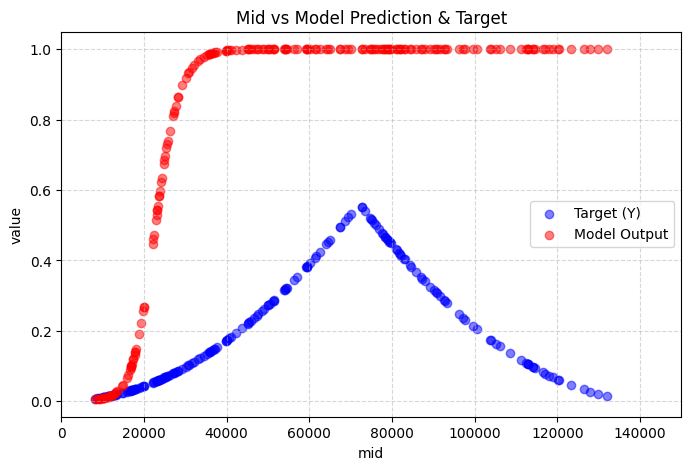

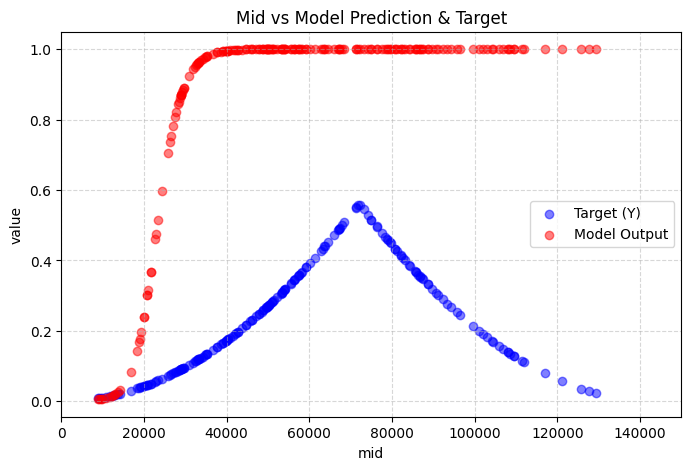

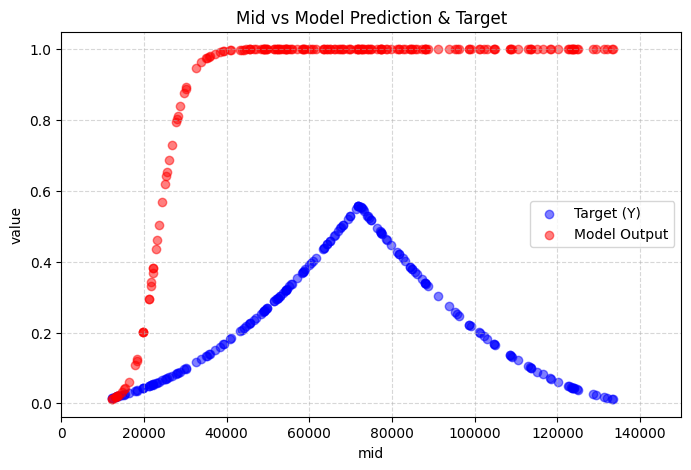

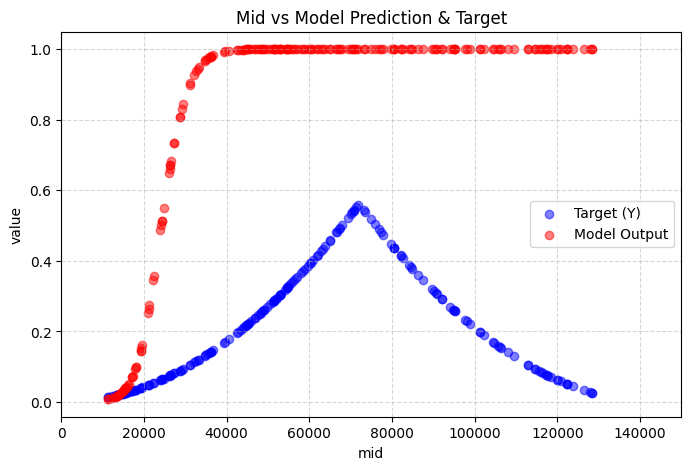

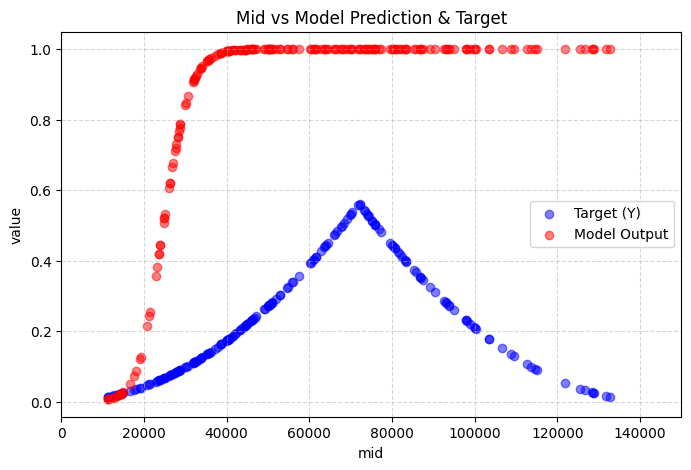

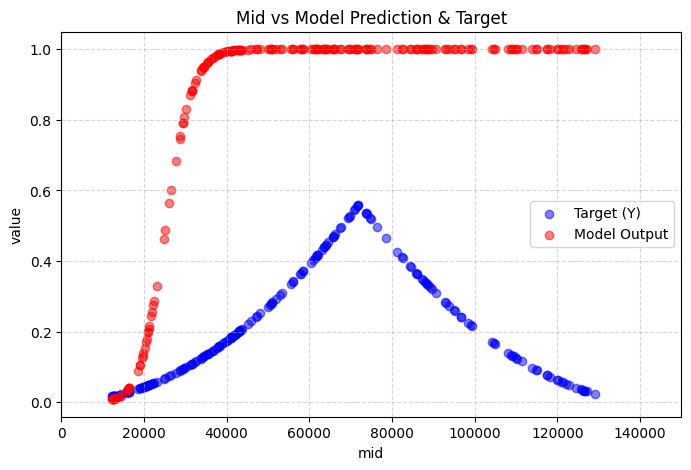

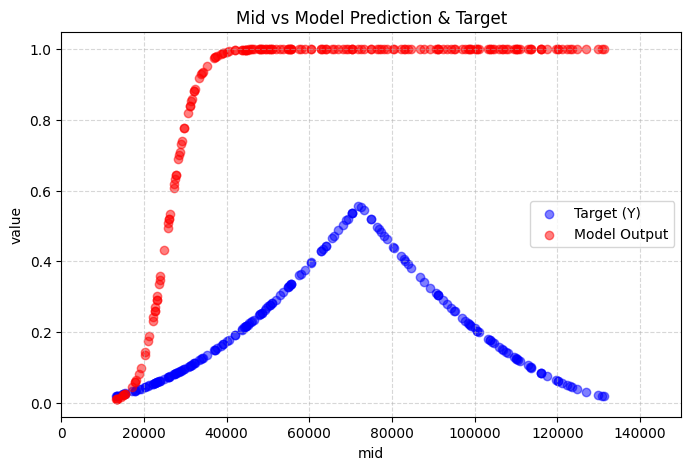

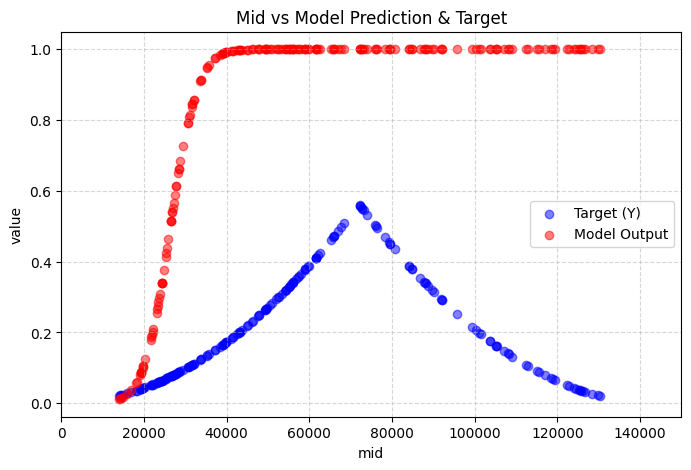

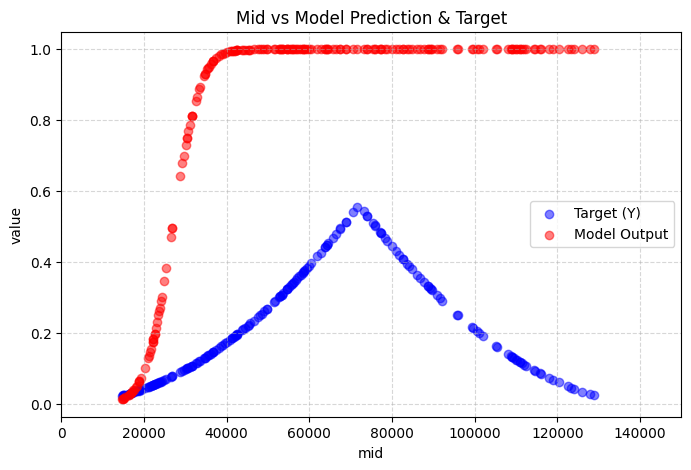

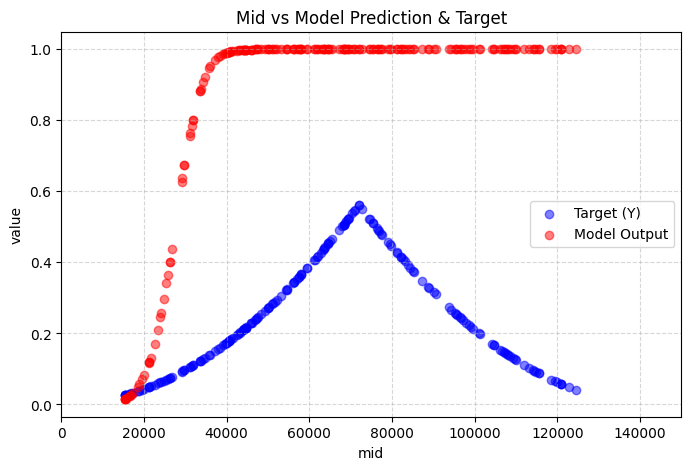

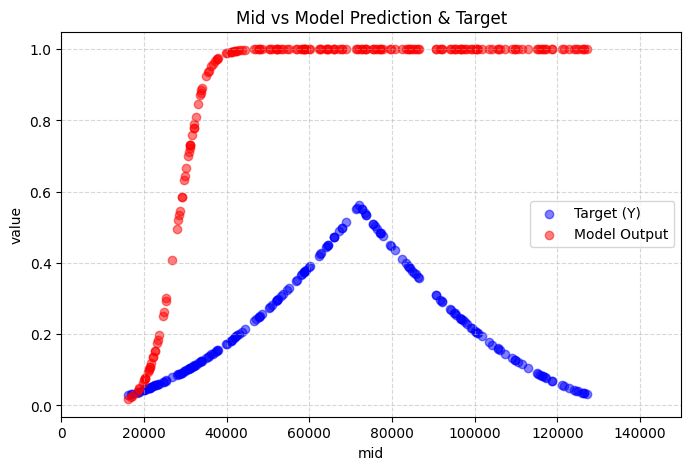

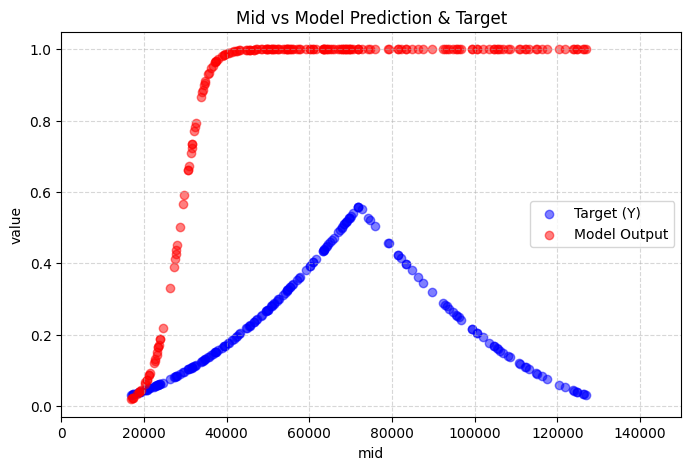

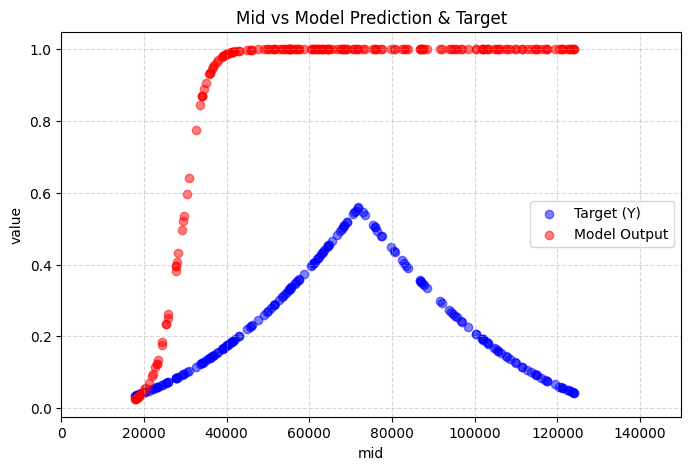

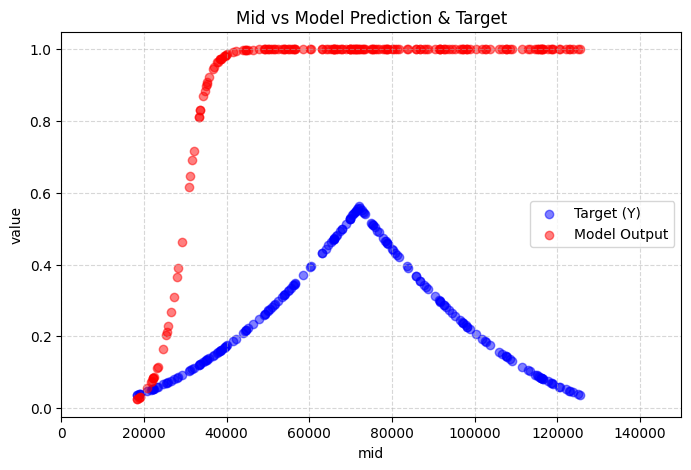

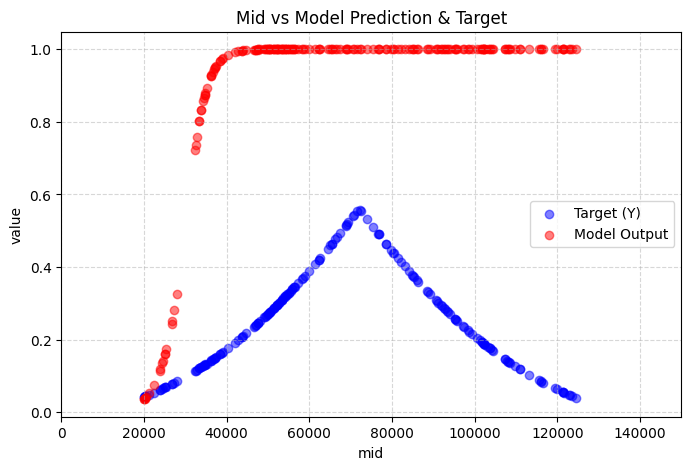

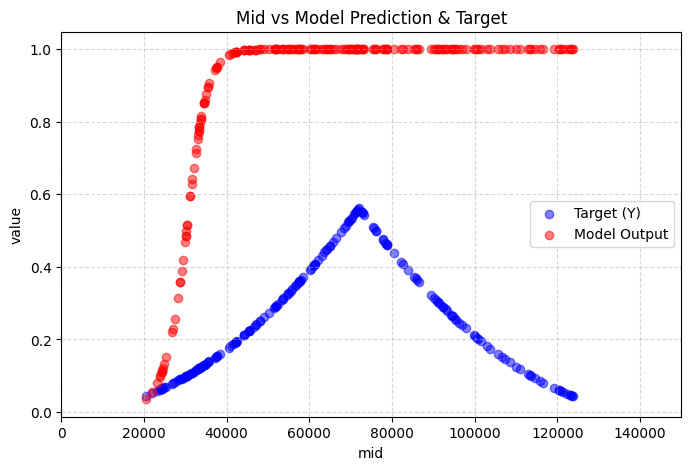

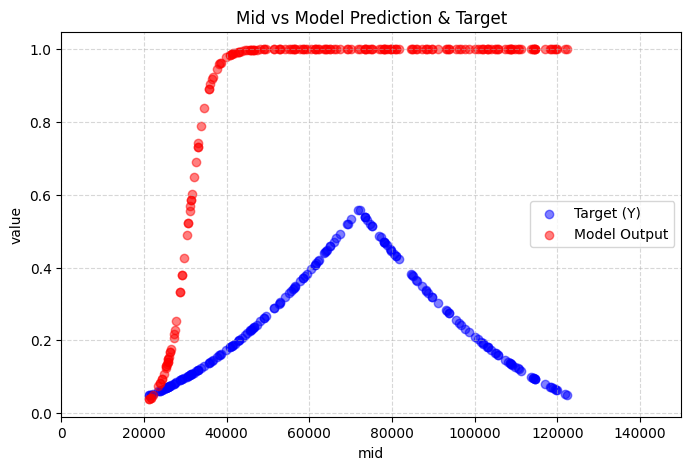

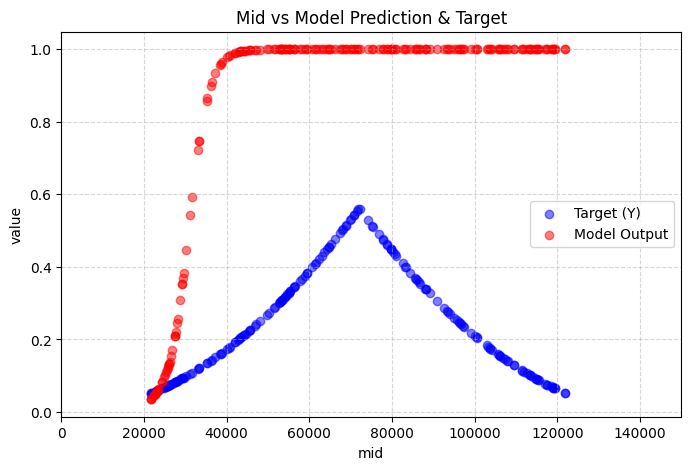

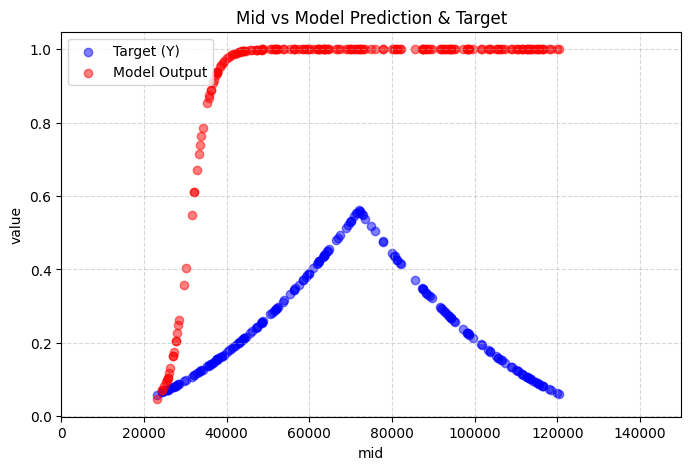

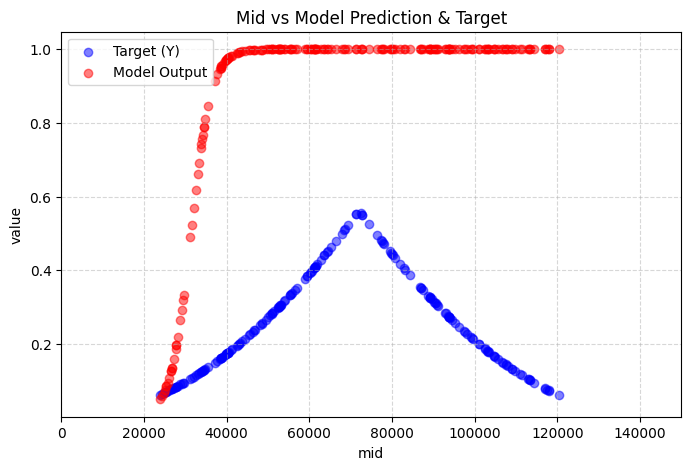

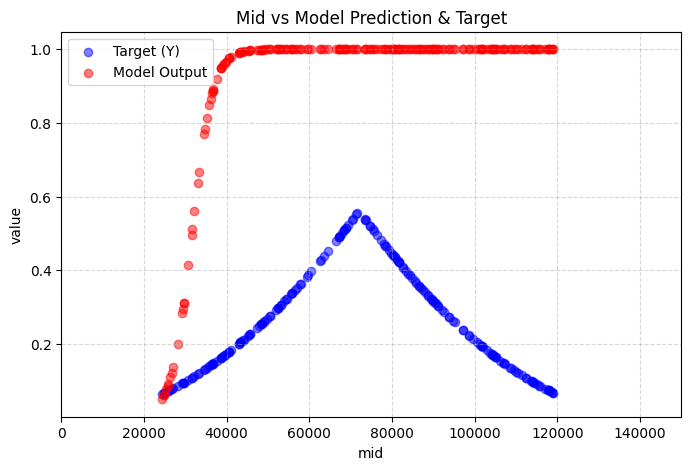

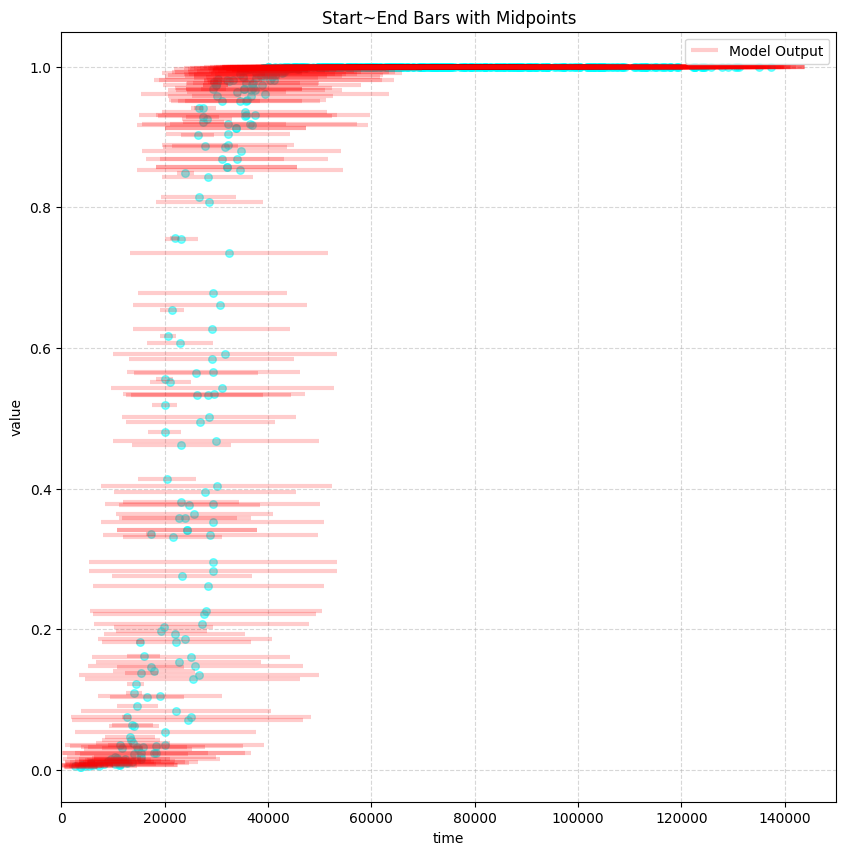

test-2s


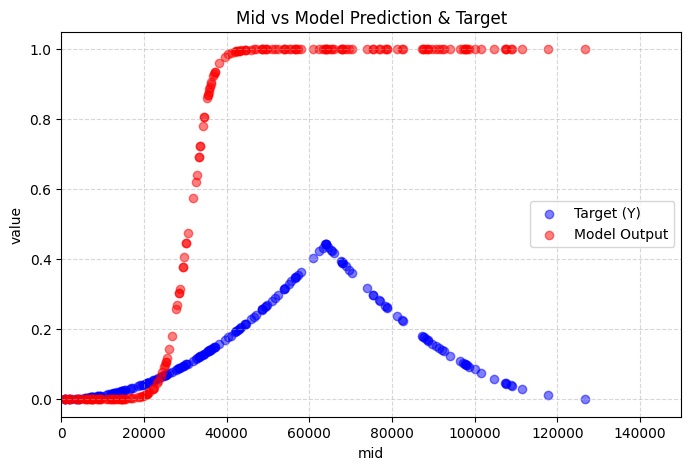

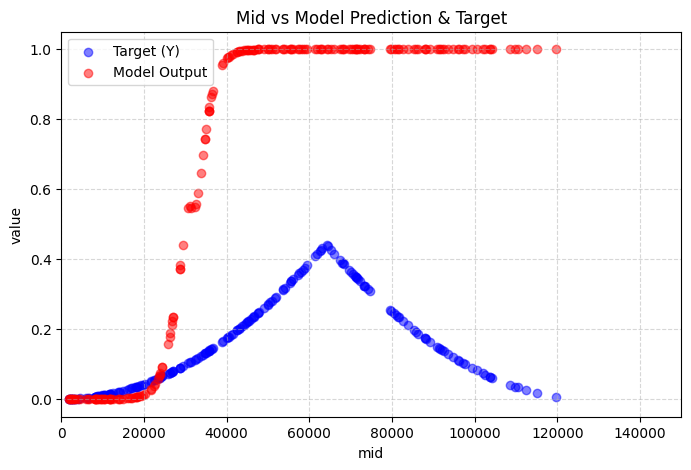

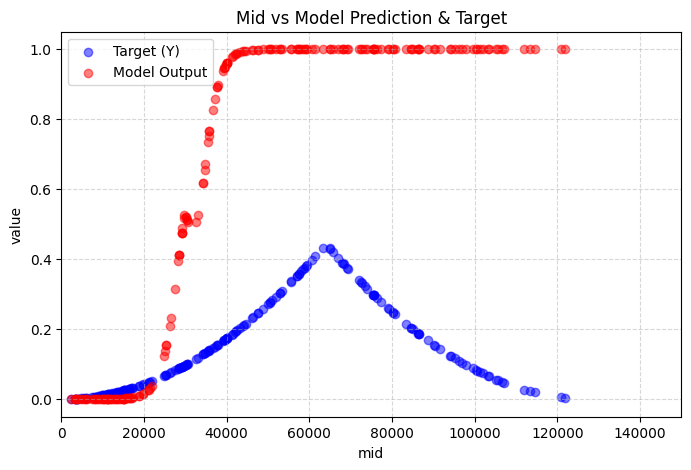

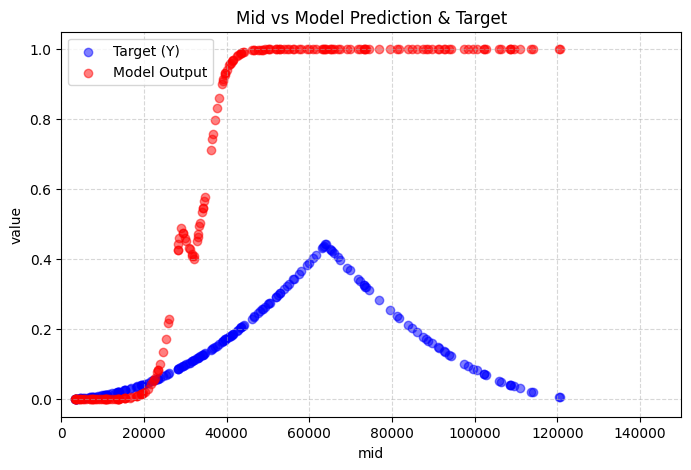

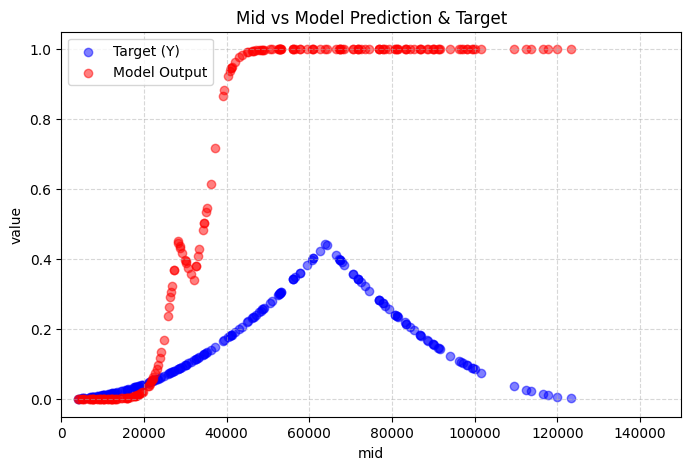

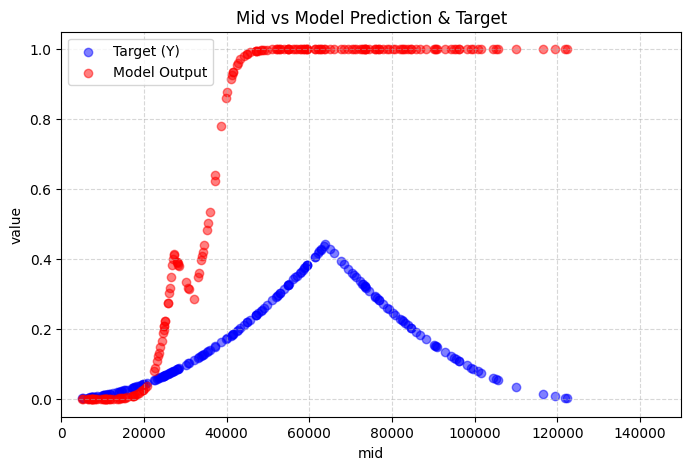

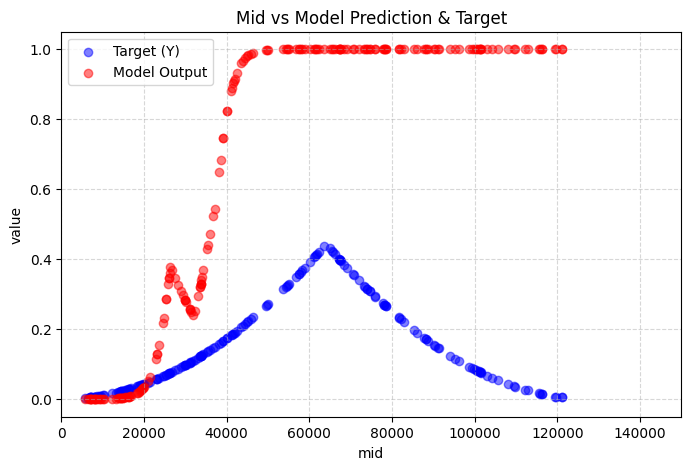

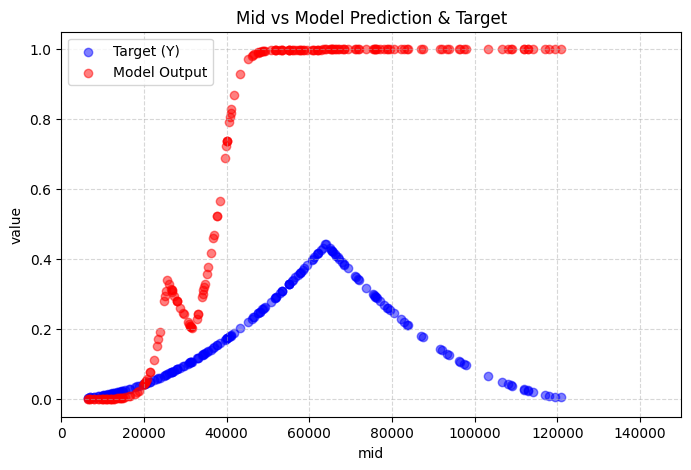

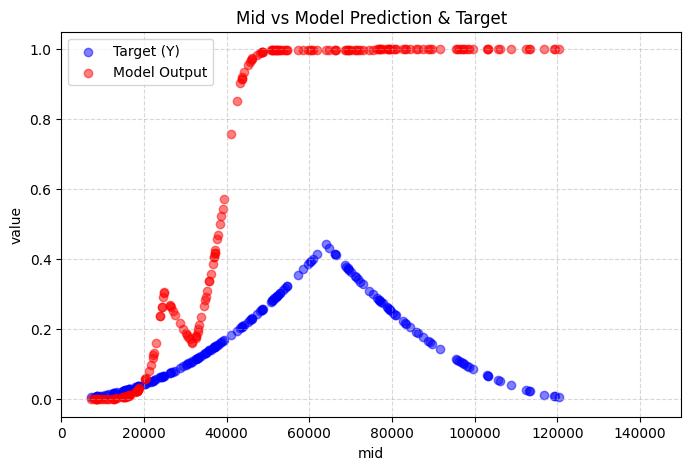

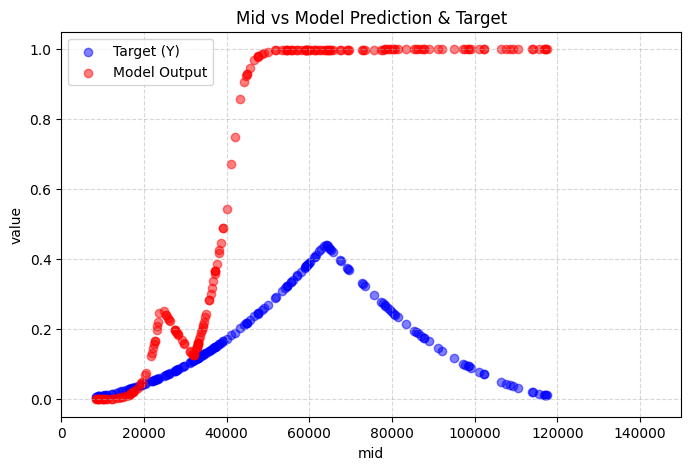

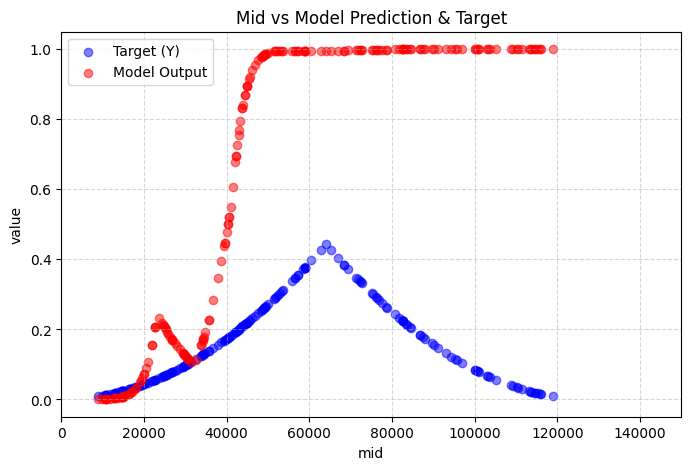

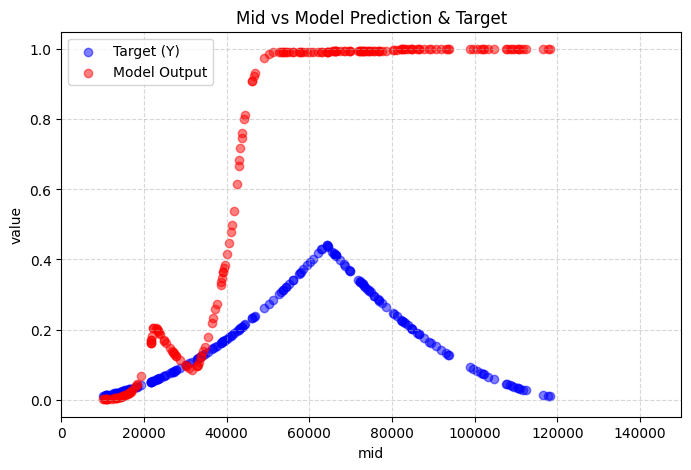

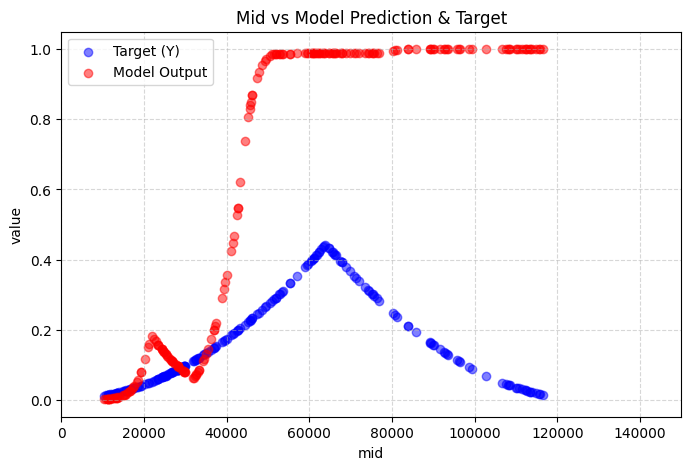

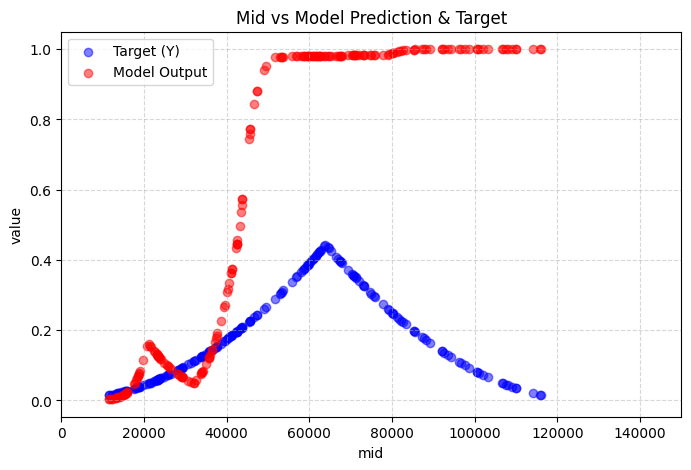

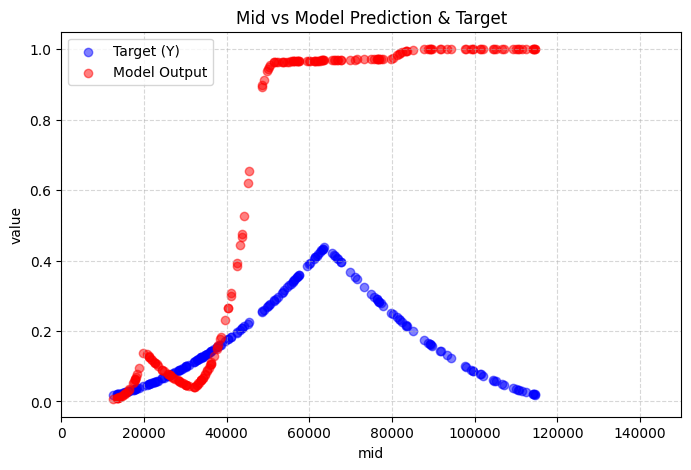

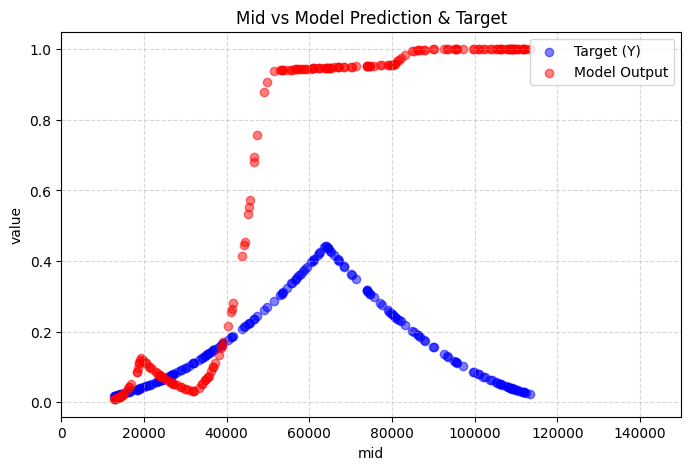

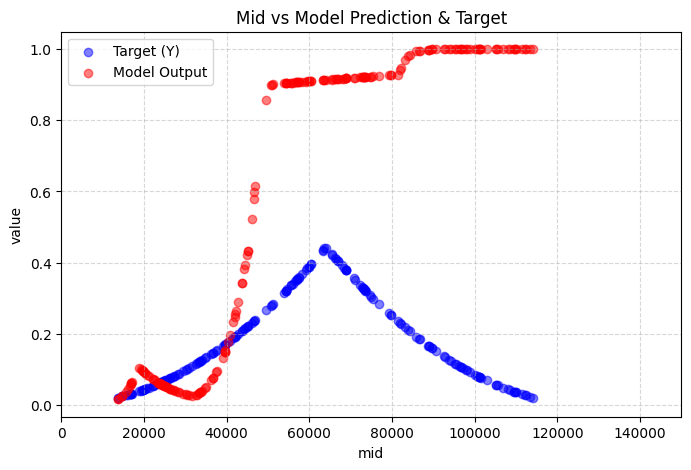

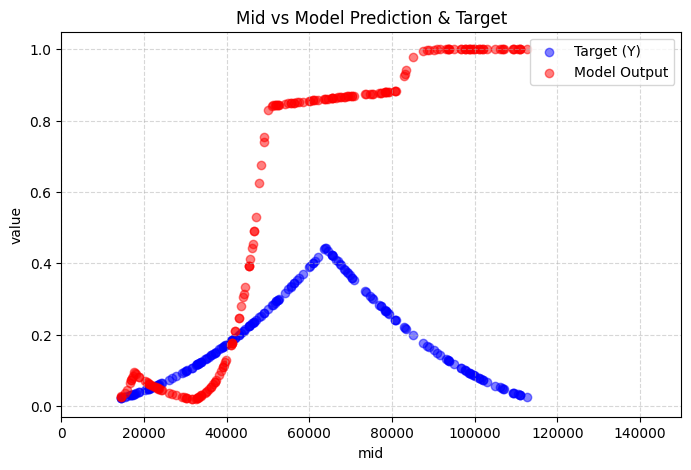

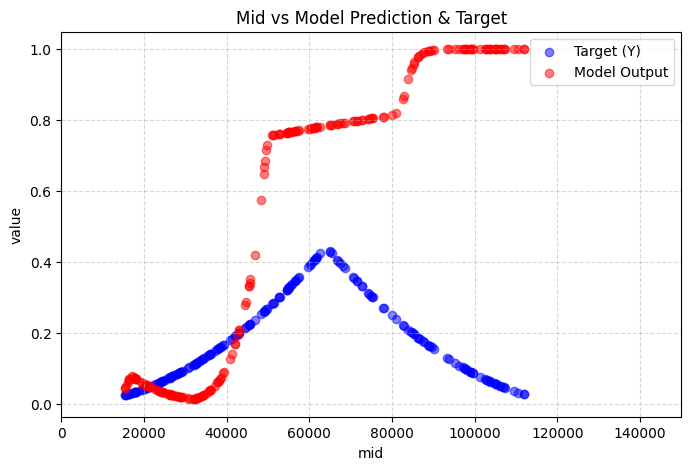

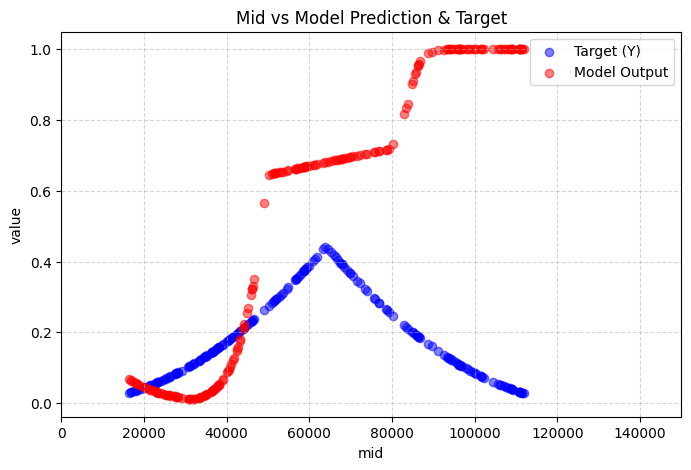

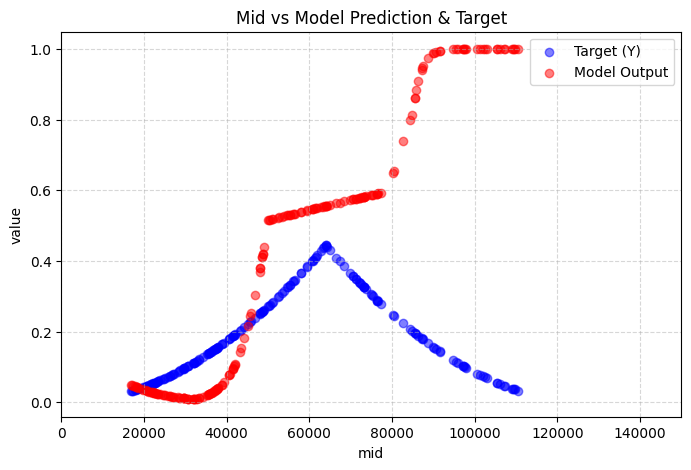

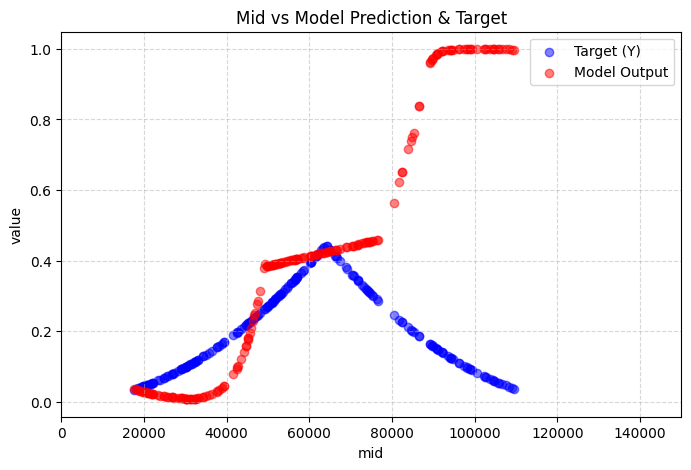

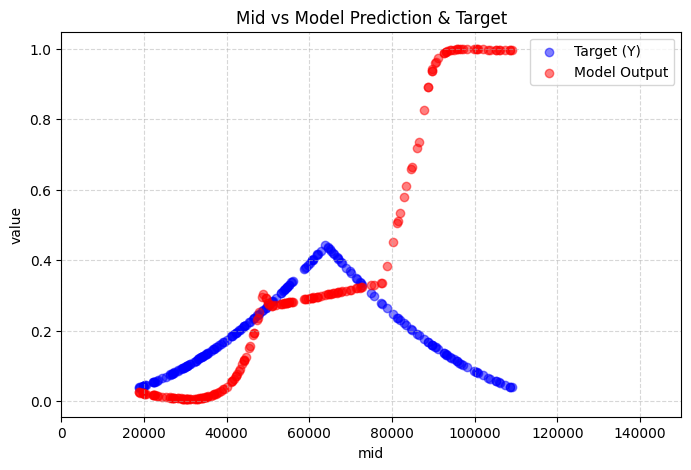

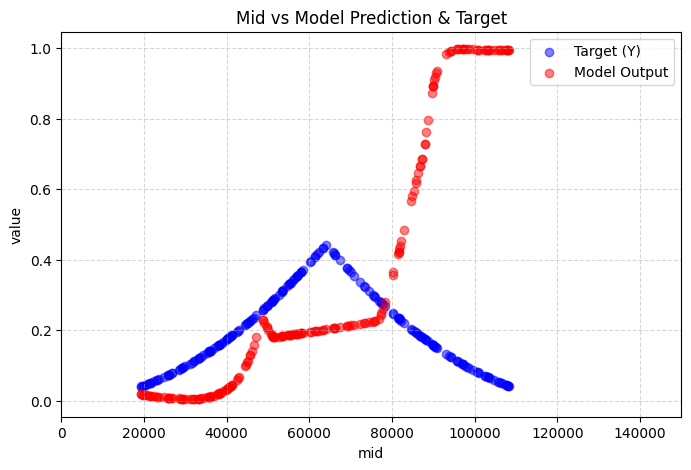

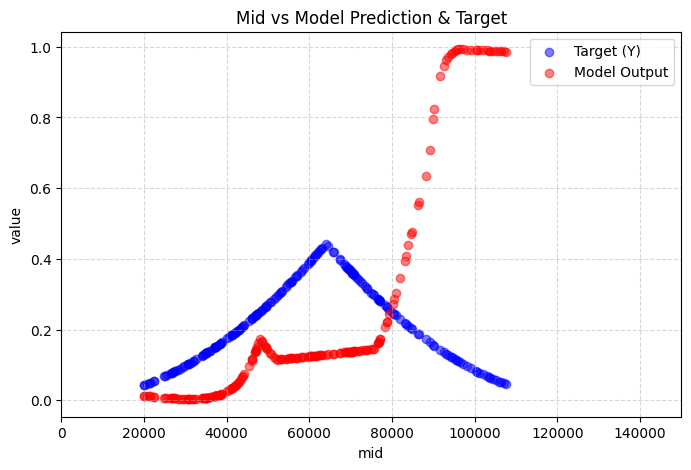

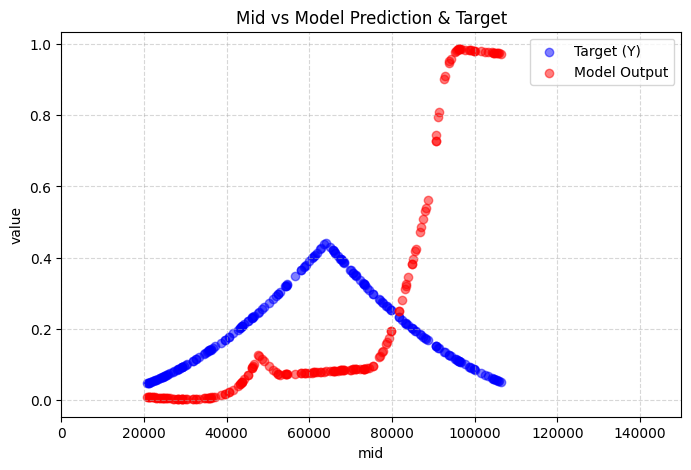

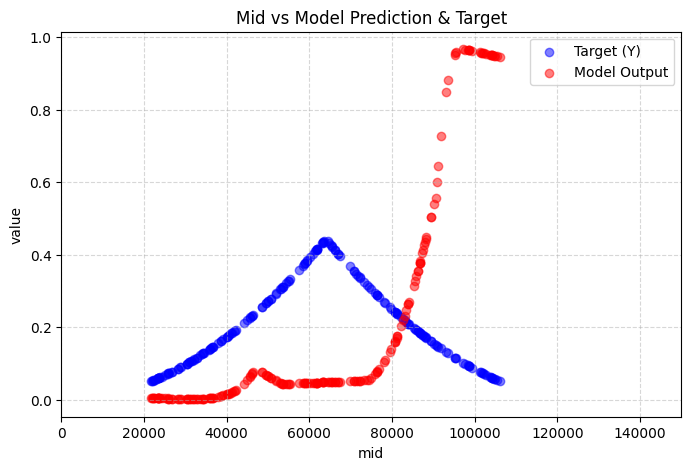

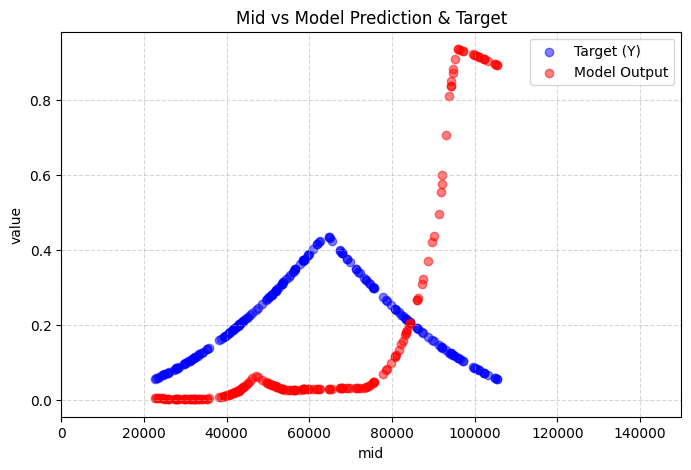

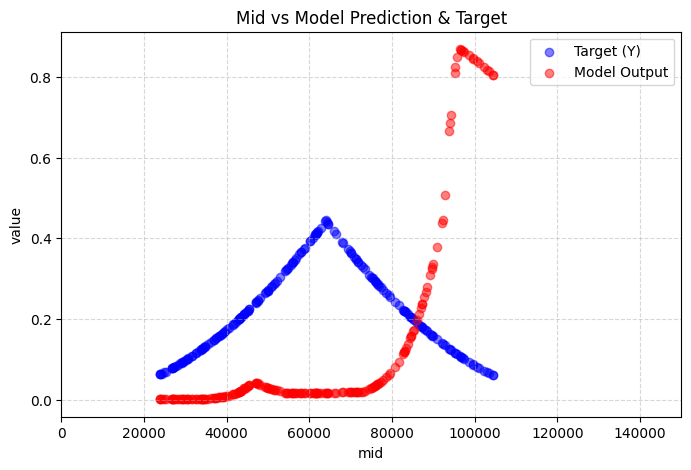

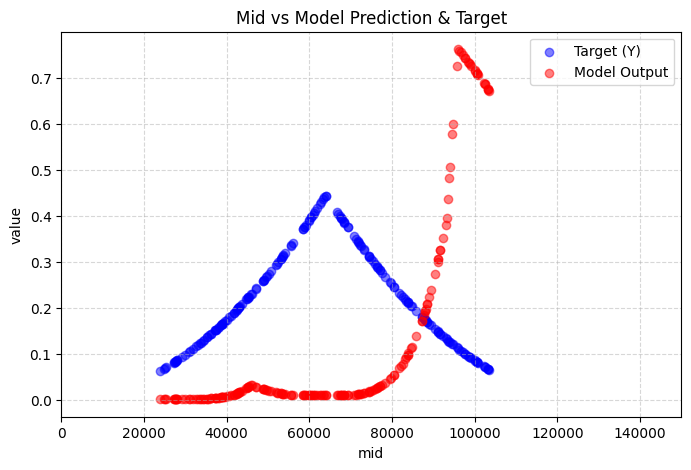

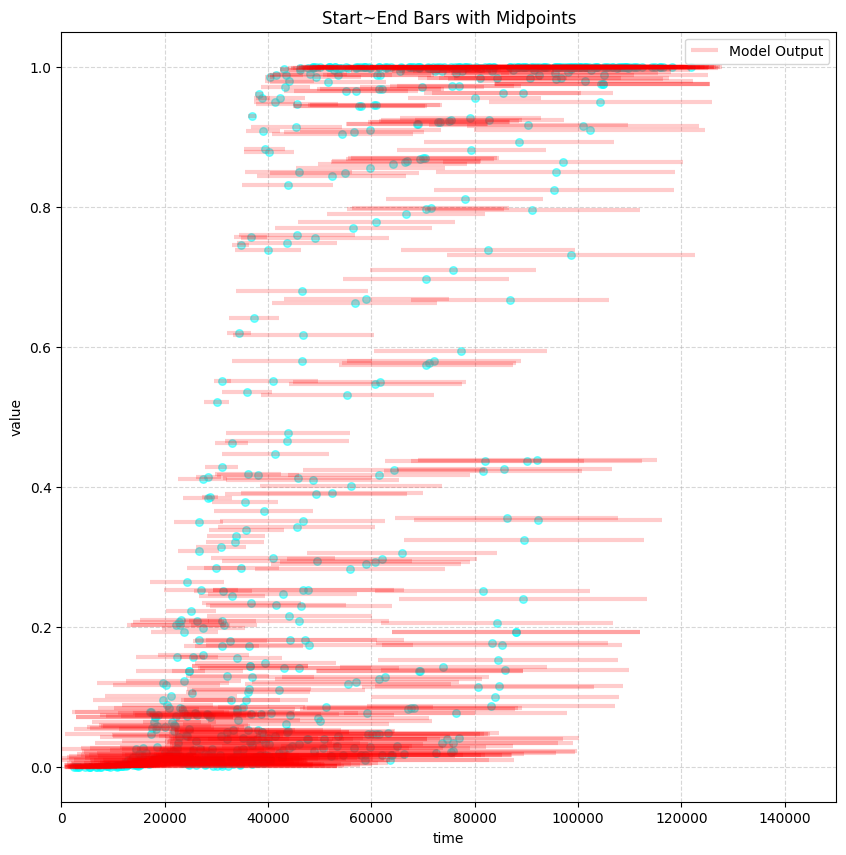

test-1s


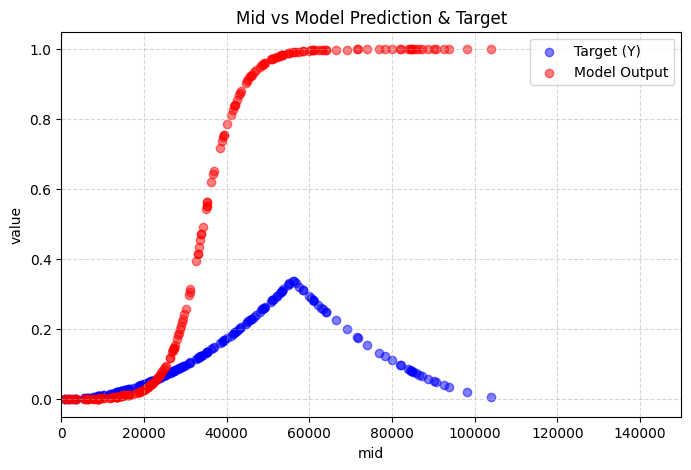

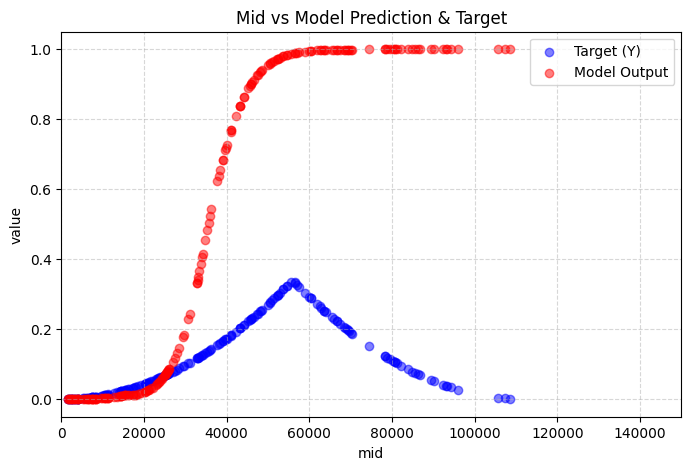

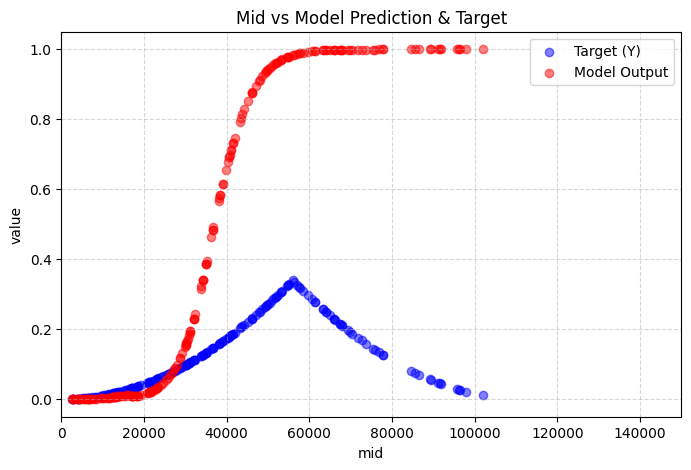

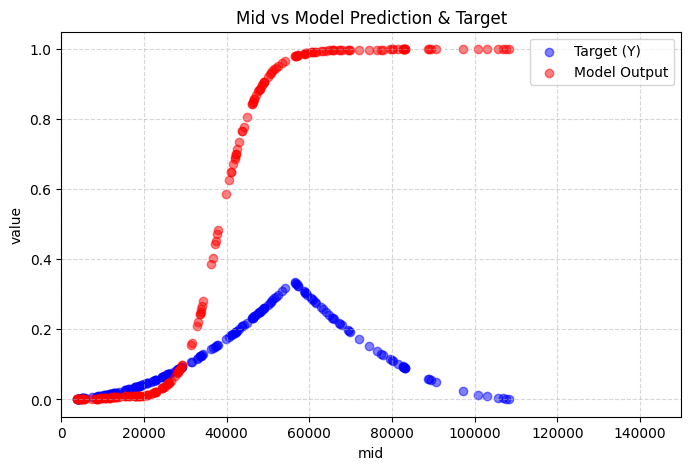

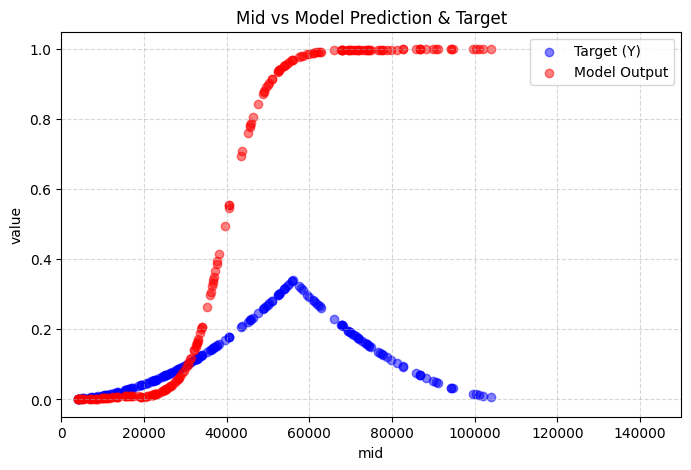

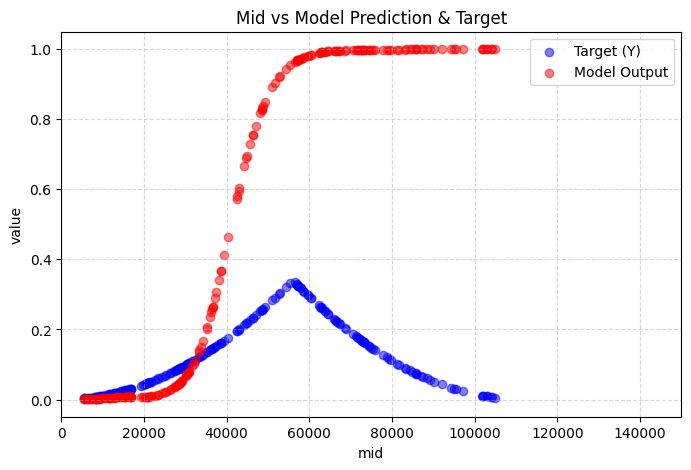

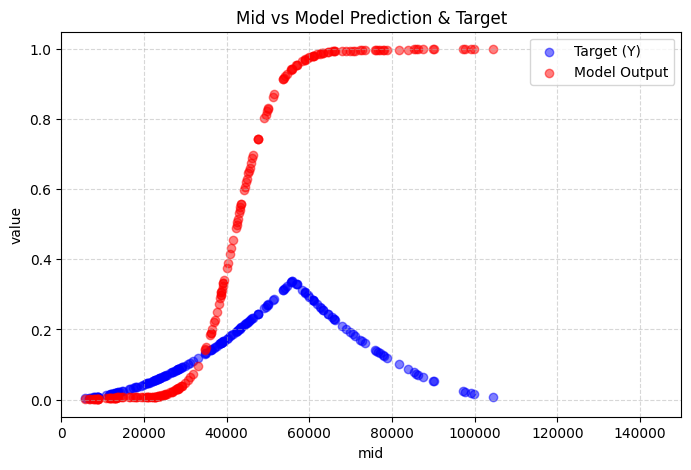

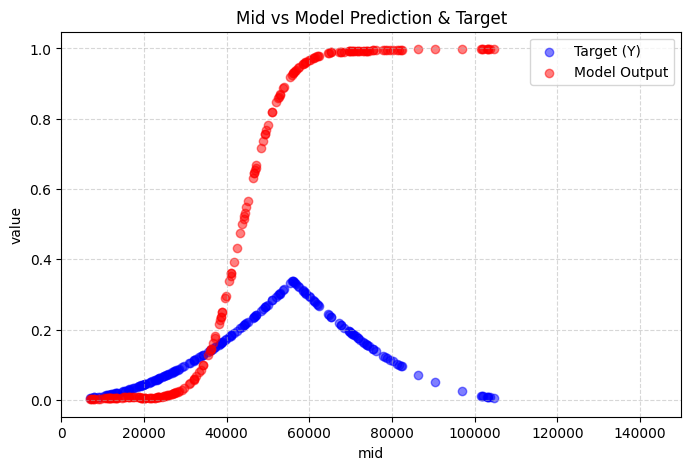

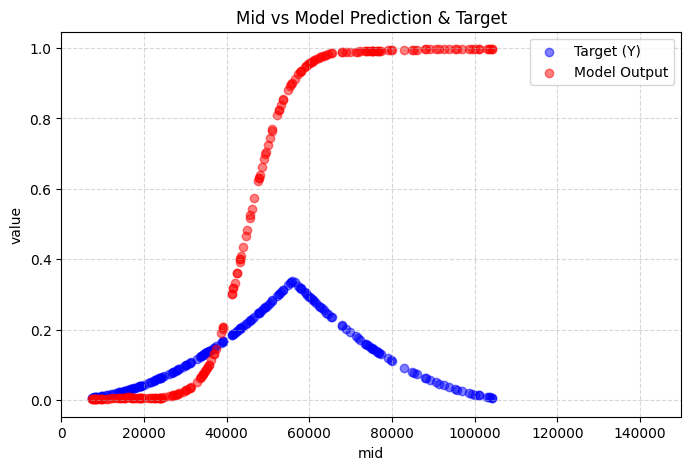

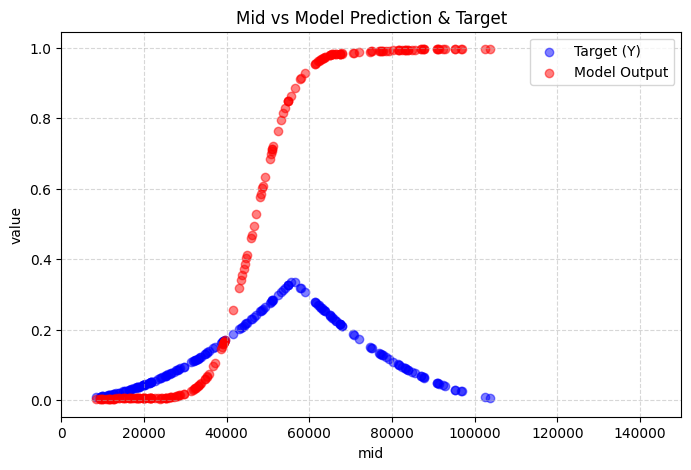

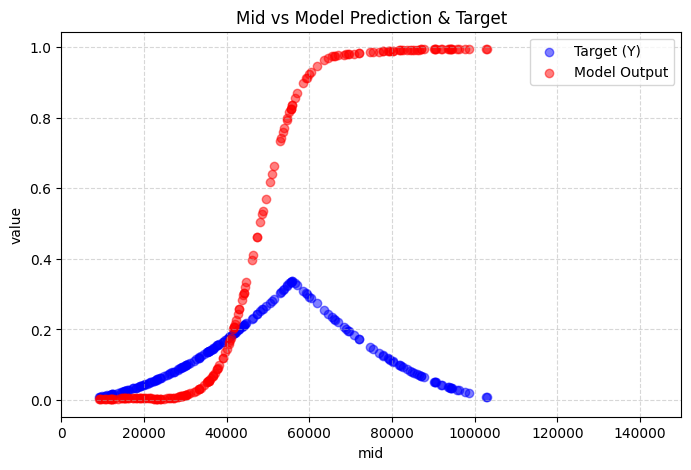

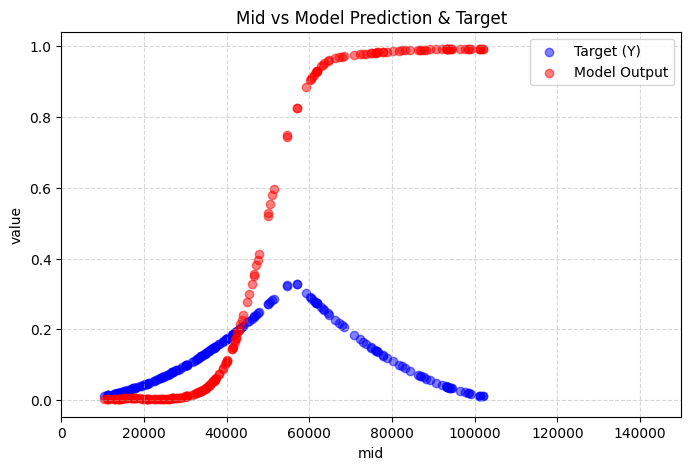

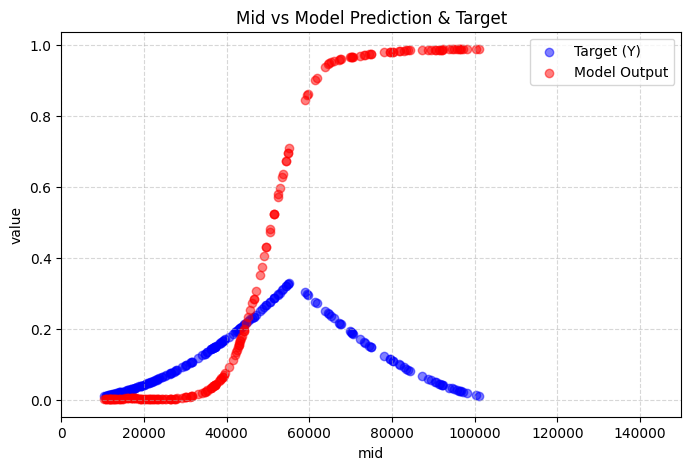

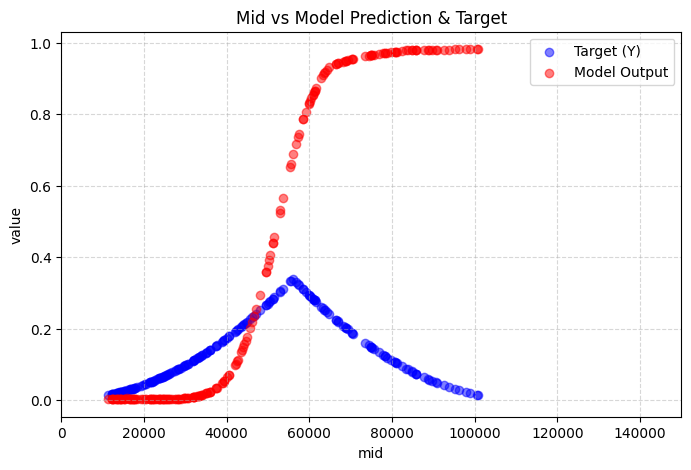

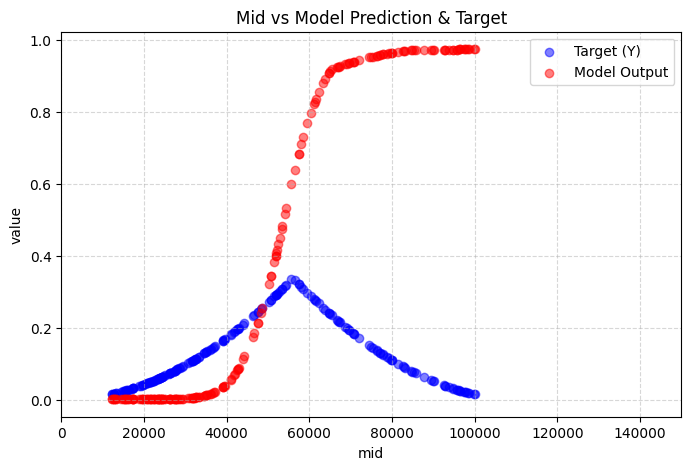

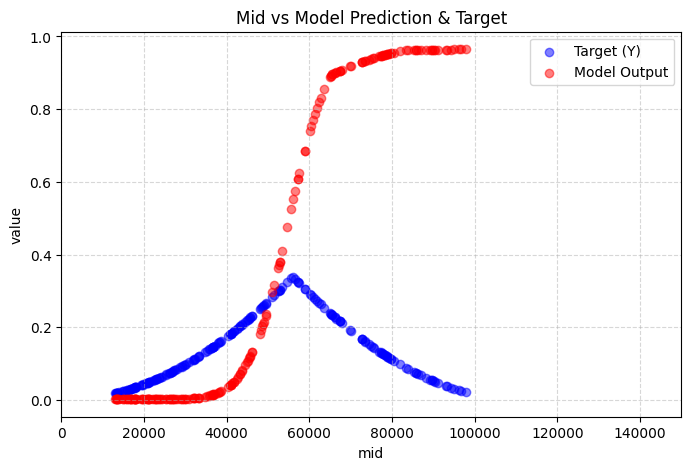

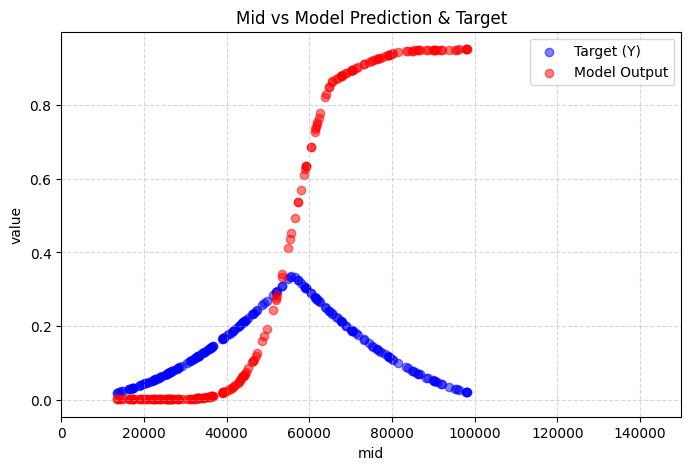

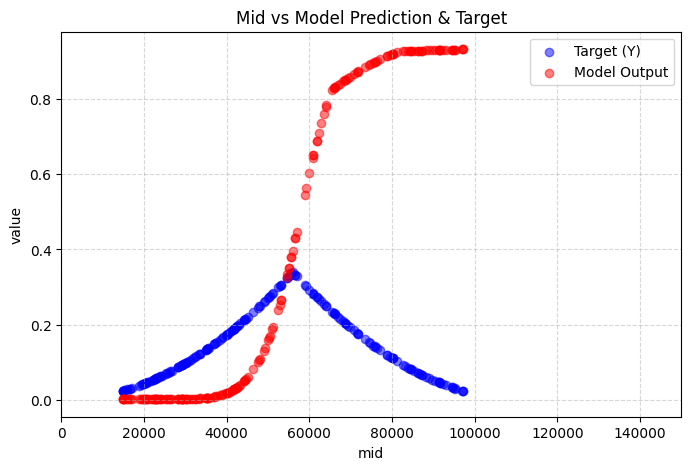

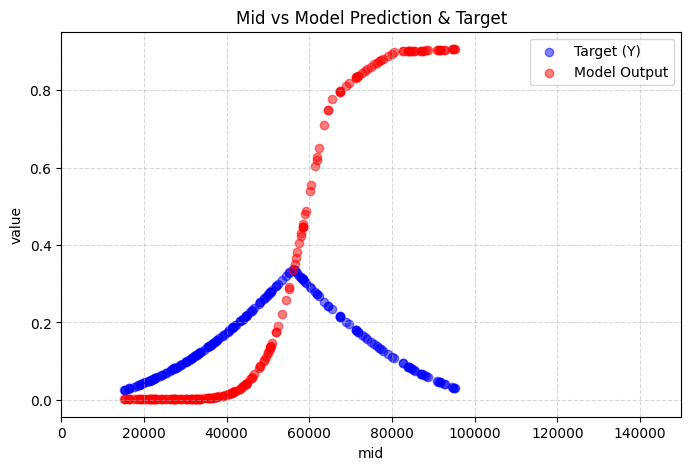

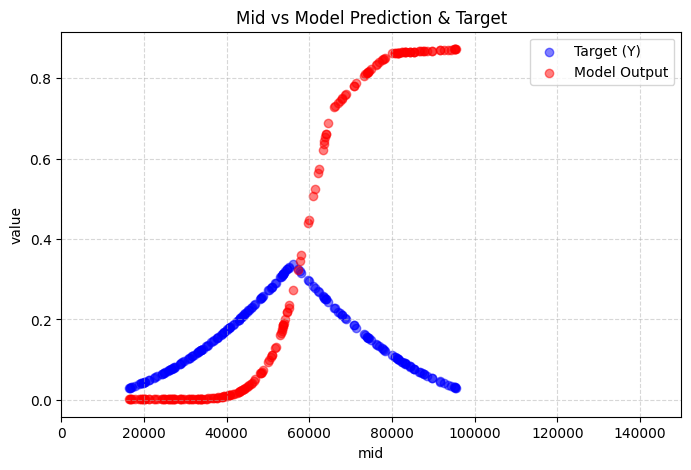

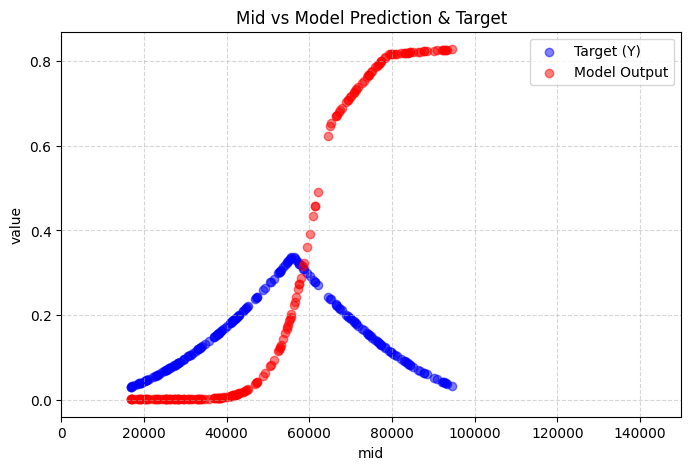

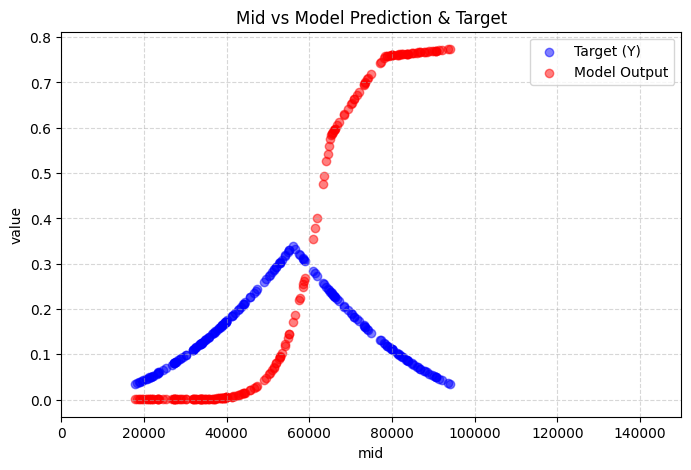

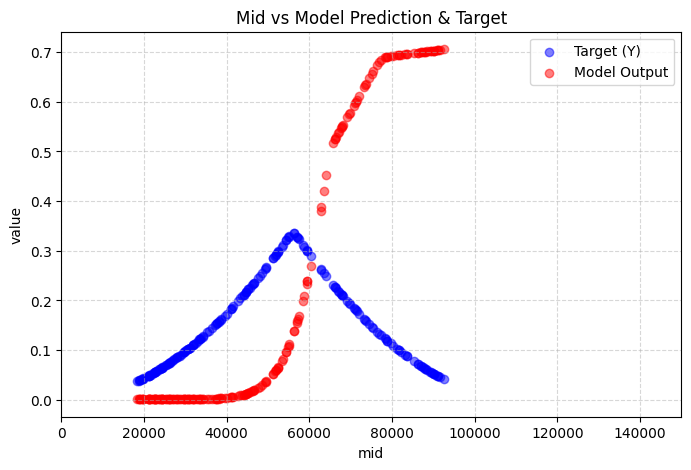

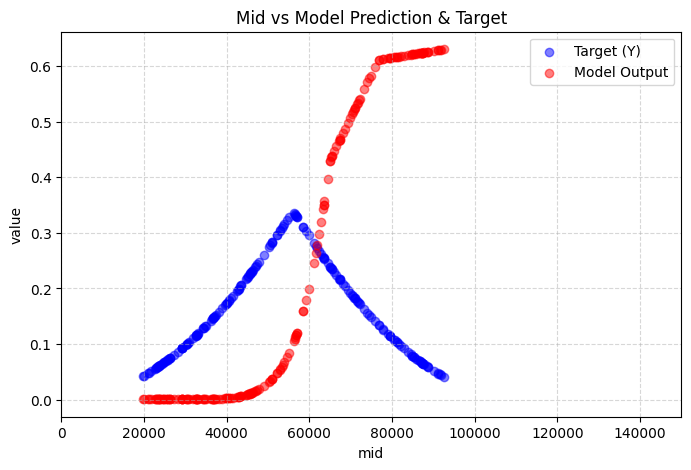

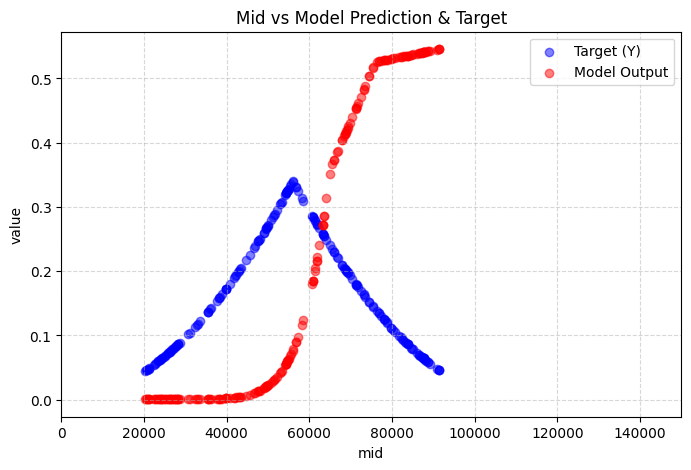

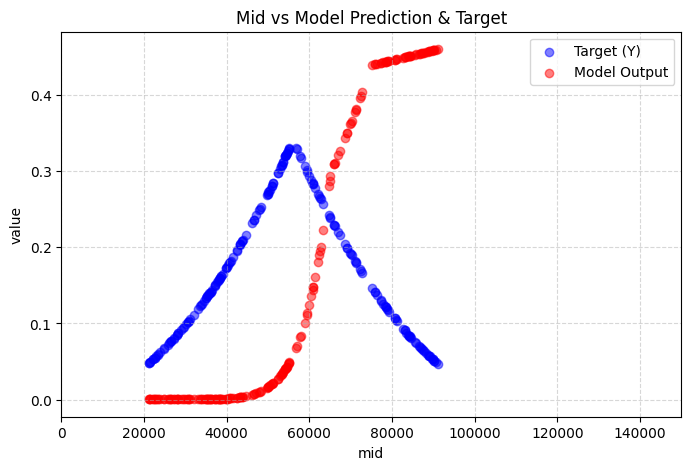

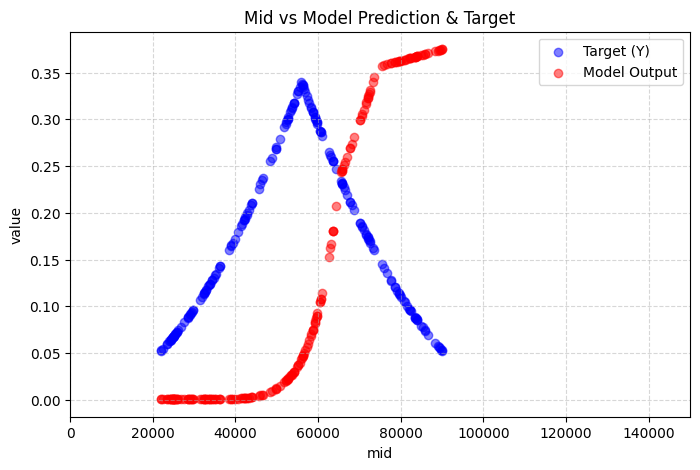

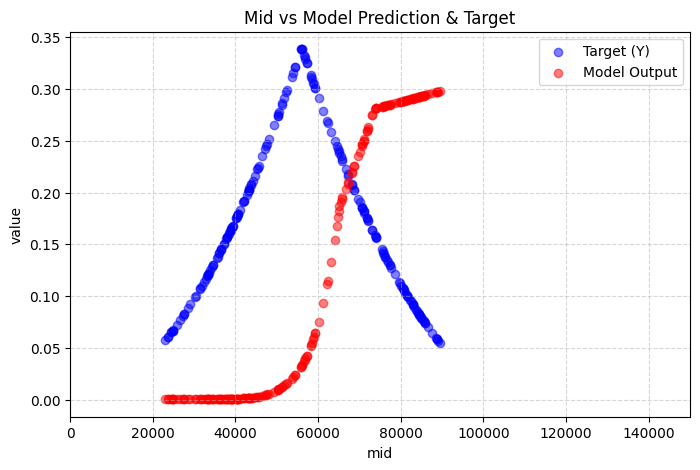

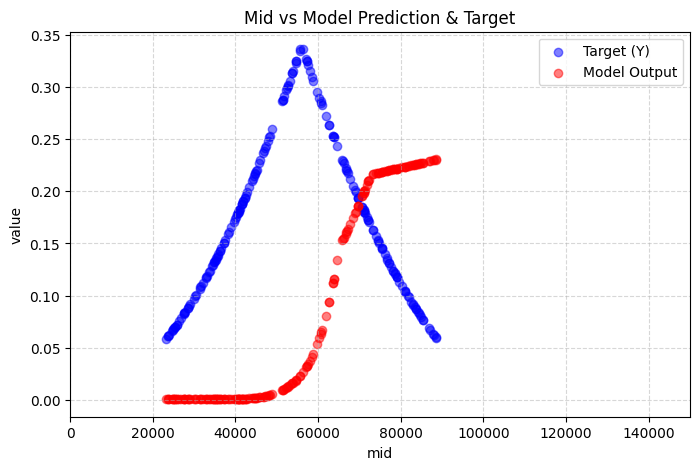

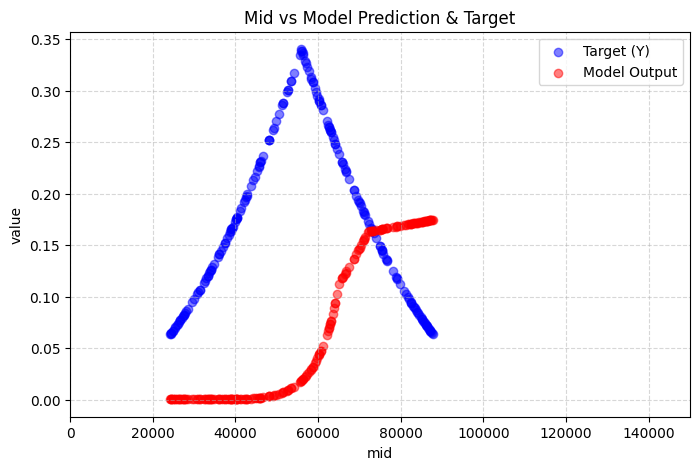

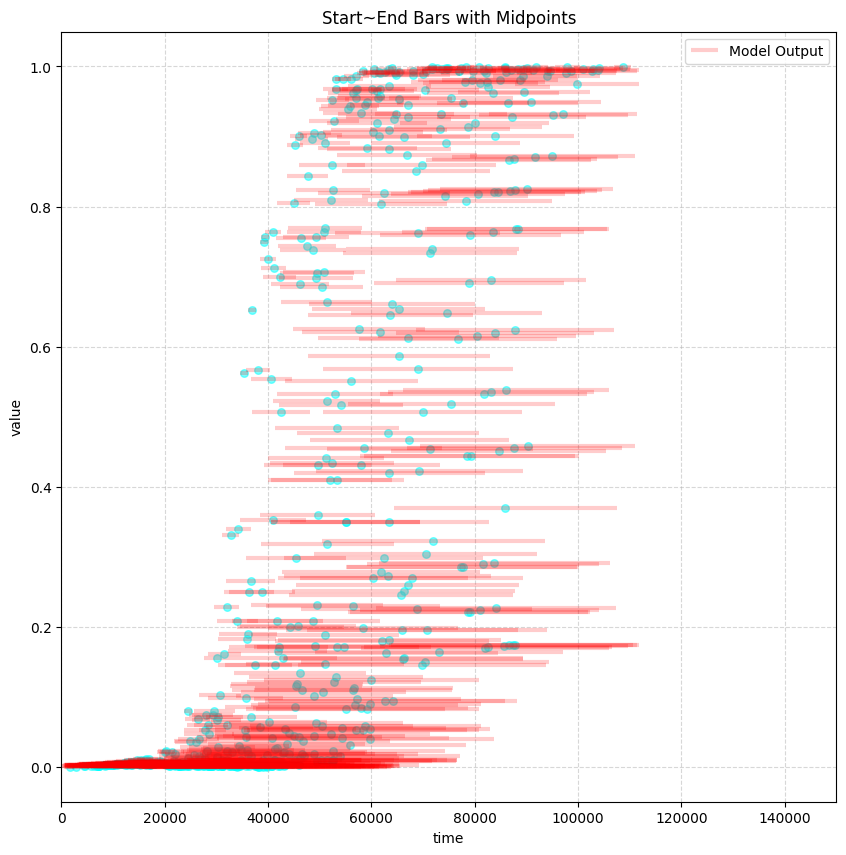

In [11]:
for name, model in b_models.items():
    print(name)
    ol = MODELS[name]["overlap_length"]
    cl = MODELS[name]["chunk_length"]
    boundary = MODELS[name]["boundary"]

    datasets = {}
    for dur in range(1600, 48000+1, 1600):
        start, end, mid = generate_data(200, length=ol + cl,dur=dur)
        x = torch.tensor(preprocess_data(start, end, mid, length=ol + cl, boundary=boundary), dtype=torch.float32)
        y = torch.tensor(approximate_data(mid, length=ol + cl, boundary=boundary), dtype=torch.float32).reshape(-1, 1)
        datasets[dur] = {
            "start": start,
            "end": end,
            "mid": mid,
            "x": x,
            "y": y
        }

    plot_with_dur(model, datasets, "cuda")